# 📓 EDIS 8100 · Week 5 · Mini Project 2: Whose Writing Gets Called Effective?

### Text-Based Analytics and Natural Language Processing on 5,531 Real Student Essays

**Estimated time:** about three focused hours in total, matching the Mini Project 2 Brief. Roughly two hours for the core path, which means running every cell top to bottom *and reading the text between them*, and roughly an hour for the interpretation memo. We launch it together in class on Wednesday, September 23, 2026, for about twenty minutes, and you finish it before the Canvas deadline.

**Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

*Guest speaker this week: Jiayi (Joyce) Zhang, University of Pennsylvania.*

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Build** a text analysis pipeline on real student writing: clean, tokenize, count, and say out loud what each cleaning decision deleted from the record.
2. **Score** stance with a lexicon small enough to read in full, then show that it explains less about a human's judgment than the crudest feature in the file does.
3. **Fit and compare** two topic models (NMF and LDA), interpret their topics against four known writing prompts, and explain why a topic model that looks brilliant here should not reassure you.
4. **Train and audit** a bag-of-words classifier against 55,068 spans of human-annotated ground truth: where it succeeds, where it collapses, and what its errors reveal about the construct.
5. **Disaggregate** both the human ratings and the model's errors by writer group, and argue about what the pattern means without pretending the data settles it.

---

## How this notebook works (read this if you are new to code)

- Click a cell and press **Shift + Enter** to run it. Work from the top down. Cells lower in the notebook depend on the ones above them.
- **Nothing here can break your computer, your grade, or the course repository.** The notebook only reads data. It never writes to anything you care about. If you would like to keep your edits, use **File > Save a copy in Drive** in Colab first.
- If something goes sideways, the fix is almost always **Runtime > Restart and run all**. Start from the top and let it go.
- Cells marked **✏️ Your turn** are yours to edit. Every one of them already contains a working answer, so the notebook runs correctly even if you change nothing. You are editing a working thing, not filling a hole.
- You will see red or pink warning text sometimes. Warnings are not errors. Only a message that says `Error` or `Traceback` needs your attention.
- Ask your neighbor before you ask the internet, and ask the instructor before you spend twenty minutes stuck.

---

## What is different about this week

Every other notebook so far has built its own data. This one downloads somebody else's, and that is the point.

Weeks 1 through 4 ran on a simulated course at a university that does not exist. That was a deliberate ethical choice and it stays defensible: we rehearsed judgment without reading anyone's records. But simulated data has a quiet flaw. It arrives clean, balanced, and arranged so that the lesson works. Real data does not arrange itself into lessons.

So this week you work on **5,531 essays actually written by United States students in grades 8 through 12**, carrying **63,211 stretches of text that human beings marked one at a time**. 55,070 of those were named as a specific argumentative move, and 55,068 of *those* also carry a human rating of how well the move worked. The remaining 8,141 are the text the annotators decided was not doing argumentative work, and you will meet them in Section 6. Nobody tidied it for you. Columns are blank. Words are misspelled. One third of the corpus is missing two demographic fields entirely, for a reason you will be able to work out. And the human ratings contain a pattern that this course exists to teach you to notice.

You will meet all of it. Where the data is broken, we will decide what to do about it in front of you, say what the decision cost, and keep going.

---

## ⚙️ Setup: where this data comes from

**You should never analyze data whose origin you cannot state.** So state it, before you load it.

### The dataset

**PERSUADE 2.0** (Persuasive Essays for Rating, Selecting, and Understanding Argumentative and Discourse Elements). A corpus of argumentative essays written by students in grades 6 through 12 in the United States, for 15 prompts across two writing tasks, independent and source-based. That is what the corpus documentation states about its origin; it does not name the schools, districts, or assessment programmes the essays came from, and neither should you. Each essay carries a **holistic score from 1 to 6** assigned by trained human raters, and each essay was then read again by human annotators who marked the **boundaries of every argumentative move in it** (the lead, the position, each claim, each counterclaim, each rebuttal, each piece of evidence, the conclusion) and rated each of those moves **Effective, Adequate, or Ineffective**.

That second layer is why we are here. Somebody sat down and marked 63,211 stretches of teenage writing, named 55,070 of them as a specific argumentative move, and rated 55,068 of those one at a time. Those judgments are the ground truth you will check your models against.

### What we are using

The full corpus covers 15 prompts and grades 6 through 12. This notebook uses a **four-prompt subset of 5,531 essays**, written by students in grades 8 through 12, hosted for this course at `github.com/HakeoungLee/edis8100-datasets`. Nothing was altered except the selection of prompts and the packaging.

### License and terms

**CC BY-NC-SA 4.0.** Attribution, non-commercial use only, share-alike. Coursework is fine. Building a product on it is not.

### How to cite it

> Crossley, S. A., Baffour, P., Tian, Y., Franklin, A., Benner, M., & Boser, U. (2024). A large-scale corpus for assessing written argumentation: PERSUADE 2.0. *Assessing Writing, 61*, 100865. https://doi.org/10.1016/j.asw.2024.100865

### The one-line story

Real students, most of them thirteen to seventeen years old, wrote to a set prompt about driverless cars, cell phone policy, distance learning, and the Electoral College. Researchers obtained those essays, hired human raters to score them and human annotators to label every argumentative move inside them, stripped the names, and released the result openly so that people like you could study writing without having to run your own assessment. Exactly which writing programmes the essays were drawn from is not stated in the release, which is itself worth noticing on a provenance card.

**That is what it cost to get this file: thousands of students' school assignments, thousands of hours of human rating, and a legal and ethical release process.** Data does not appear. Somebody's work is always underneath it, and in this case some of that work was done by children.

In [1]:
# ============================================================================
# Load this week's data from the course dataset repository. No downloads to
# your computer, no logins, no API keys. Takes about a second.
# ============================================================================
import pandas as pd

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

try:
    essays = pd.read_csv(f"{BASE}/persuade-4prompts/essays.csv.gz")
    spans = pd.read_csv(f"{BASE}/persuade-4prompts/discourse_elements.csv.gz")
except Exception:
    print("=" * 78)
    print("The data did not download, and that is almost always the network,")
    print("not you. Here is what to check, in order:")
    print()
    print("  1. Are you online? Reload any web page to be sure.")
    print("  2. Try running this cell again. Transient failures are common.")
    print("  3. Confirm the dataset repository is reachable in a browser tab:")
    print("     https://github.com/HakeoungLee/edis8100-datasets")
    print("  4. If you are on a locked-down campus or hospital network, it may")
    print("     be blocking raw.githubusercontent.com. Try a different network,")
    print("     or run this notebook in Google Colab instead.")
    print()
    print("If it is still failing after all four, post on Canvas with a")
    print("screenshot. Do not spend twenty minutes alone with this.")
    print("=" * 78)
    raise RuntimeError(
        "Could not download the PERSUADE data from edis8100-datasets. "
        "See the message printed above."
    ) from None

print("Data arrived. Here is what you have.")
print()
print(f"  essays.csv.gz              {essays.shape[0]:>6,} essays  x {essays.shape[1]:>2} columns")
print(f"  discourse_elements.csv.gz  {spans.shape[0]:>6,} spans   x {spans.shape[1]:>2} columns")
print()
print(f"  Written by students in grades {int(essays['grade_level'].min())} "
      f"through {int(essays['grade_level'].max())}.")
print(f"  {essays['prompt_name'].nunique()} writing prompts. "
      f"{essays['essay_word_count'].sum():,} words of student writing in total.")
print(f"  {spans['discourse_effectiveness'].notna().sum():,} of the spans carry a "
      f"human rating of how well the move worked.")
print()
print("PERSUADE 2.0, CC BY-NC-SA 4.0. Crossley et al. (2024), Assessing Writing 61.")

Data arrived. Here is what you have.

  essays.csv.gz               5,531 essays  x 13 columns
  discourse_elements.csv.gz  63,211 spans   x  8 columns

  Written by students in grades 8 through 12.
  4 writing prompts. 2,470,005 words of student writing in total.
  55,068 of the spans carry a human rating of how well the move worked.

PERSUADE 2.0, CC BY-NC-SA 4.0. Crossley et al. (2024), Assessing Writing 61.


Now the tools. Four libraries, all of them already installed in Colab: **pandas** for tables, **numpy** for arrays and arithmetic, **matplotlib** for figures, and **scikit-learn** for the vectorizers, the two topic models, and the classifiers. There is nothing to install, which is a deliberate design choice: an analysis that only runs on a machine with the right installs is an analysis your reader cannot check.

In [2]:
%matplotlib inline

import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.metrics import (adjusted_rand_score, accuracy_score, f1_score,
                             recall_score, classification_report)
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.autolayout': True,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RANDOM_STATE = 8100      # the course seed, so your numbers match your classmates'

# A colorblind-safe palette (Paul Tol's bright set). Nothing here relies on
# telling red from green.
BLUE, ROSE, GREEN, YELLOW, CYAN, PURPLE, GREY = (
    '#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB')

# Short names for the four prompts, because the real ones are paragraphs long.
PROMPT_SHORT = {
    'Does the electoral college work?': 'electoral college',
    'Distance learning': 'distance learning',
    'Driverless cars': 'driverless cars',
    'Cell phones at school': 'cell phones',
}
essays['prompt_short'] = essays['prompt_name'].map(PROMPT_SHORT)

print('Libraries loaded. Random seed:', RANDOM_STATE)
print('Prompts, shortened for readability:')
for long, short in PROMPT_SHORT.items():
    print(f'   {short:<20} <- "{long[:52]}..."')

Libraries loaded. Random seed: 8100
Prompts, shortened for readability:
   electoral college    <- "Does the electoral college work?..."
   distance learning    <- "Distance learning..."
   driverless cars      <- "Driverless cars..."
   cell phones          <- "Cell phones at school..."


---

## 📊 1. Meet the corpus

Before any modeling, look at the thing. A corpus is not an abstraction: it is a pile of writing that people did, and the first job is to know how big the pile is, who is in it, and who is missing from it.

Two files, two grain sizes. `essays` has **one row per essay**. `spans` has **one row per argumentative move inside an essay**, so a single essay contributes many rows. Getting the grain right is most of data work, and getting it wrong is how you end up reporting that you have sixty thousand students.

In [3]:
print('ESSAYS: one row per essay')
print('  shape:', essays.shape)
print('  columns:', list(essays.columns))
print()
print('SPANS: one row per argumentative move inside an essay')
print('  shape:', spans.shape)
print('  columns:', list(spans.columns))
print()
print(f'  So the average essay contributes {len(spans) / len(essays):.2f} spans, '
      f'and {spans["essay_id"].nunique():,} of the {len(essays):,} essays have at least one.')
print()
print('The four prompts, and what they asked for:')
overview = essays.groupby('prompt_short').agg(
    essays=('essay_id', 'size'),
    task_type=('task', 'first'),
    mean_score=('holistic_essay_score', 'mean'),
    mean_words=('essay_word_count', 'mean'),
).round(2).sort_values('essays', ascending=False)
print(overview.to_string())
print()
print('Grade levels represented:')
print(essays['grade_level'].astype(int).value_counts().sort_index().to_string())
print()
print('Essay length, in words:')
print(essays['essay_word_count'].describe().round(1).to_string())

ESSAYS: one row per essay
  shape: (5531, 14)
  columns: ['essay_id', 'prompt_name', 'task', 'assignment', 'holistic_essay_score', 'essay_word_count', 'grade_level', 'gender', 'ell_status', 'race_ethnicity', 'economically_disadvantaged', 'student_disability_status', 'full_text', 'prompt_short']

SPANS: one row per argumentative move inside an essay
  shape: (63211, 8)
  columns: ['essay_id', 'discourse_id', 'discourse_start', 'discourse_end', 'discourse_type', 'discourse_type_num', 'discourse_effectiveness', 'discourse_text']

  So the average essay contributes 11.43 spans, and 5,531 of the 5,531 essays have at least one.

The four prompts, and what they asked for:
                   essays       task_type  mean_score  mean_words
prompt_short                                                     
electoral college    1818  Text dependent        3.01      431.15
distance learning    1498     Independent        4.41      586.32
driverless cars      1386  Text dependent        3.20      402

Three things worth pausing on in that printout.

**"Text dependent" versus "Independent" is not a footnote.** Two prompts (electoral college, driverless cars) gave students a source article to read and required them to use it. Two did not. Those are different writing tasks, and any word-level comparison across them is partly a comparison of the source articles the students were handed.

**The prompts have very different mean scores.** Distance learning averages 4.41 and the electoral college prompt averages 3.01. Before you conclude anything about students, notice that this is a fact about the essays and the raters, and you have no way to separate "harder prompt" from "different students" from "different rating panel."

**The prompts have very different mean lengths too:** 586 words for distance learning, 302 for cell phones. Hold that thought. In Section 4 it becomes the most important number in this notebook.

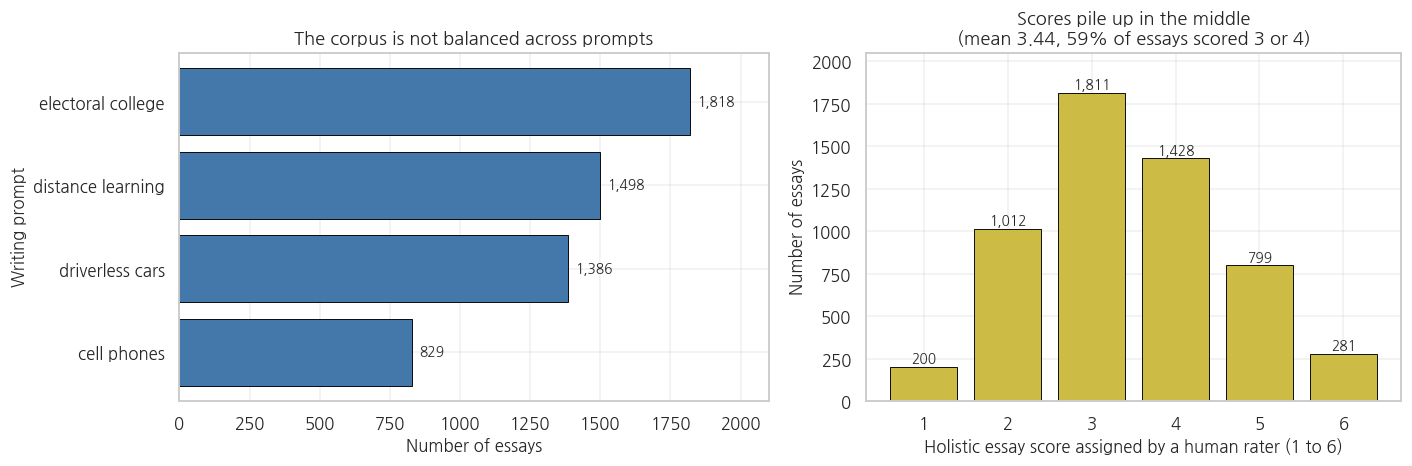

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1.1, 1]})

# Panel 1: essays per prompt
counts = essays['prompt_short'].value_counts().sort_values()
axes[0].barh(counts.index, counts.values, color=BLUE, edgecolor='black', linewidth=0.6)
for y, v in enumerate(counts.values):
    axes[0].text(v + 25, y, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Number of essays')
axes[0].set_ylabel('Writing prompt')
axes[0].set_title('The corpus is not balanced across prompts')
axes[0].set_xlim(0, 2100)

# Panel 2: holistic score distribution
dist = essays['holistic_essay_score'].value_counts().sort_index()
axes[1].bar(dist.index, dist.values, color=YELLOW, edgecolor='black', linewidth=0.6)
for x, v in zip(dist.index, dist.values):
    axes[1].text(x, v + 25, f'{v:,}', ha='center', fontsize=9)
axes[1].set_xlabel('Holistic essay score assigned by a human rater (1 to 6)')
axes[1].set_ylabel('Number of essays')
axes[1].set_title(f'Scores pile up in the middle\n(mean {essays["holistic_essay_score"].mean():.2f}, '
                  f'{(dist.loc[3] + dist.loc[4]) / len(essays):.0%} of essays scored 3 or 4)')
axes[1].set_xticks(list(dist.index))
axes[1].set_ylim(0, 2050)

plt.show()

**🧠 Interpret this figure before you move on.** Two facts, and one habit.

The left panel: the electoral college prompt supplies 1,818 essays and the cell phone prompt supplies 829, so the corpus is more than twice as much one thing as the other. Any model fit on all four at once will hear the loudest prompt best. That is not a flaw to fix, it is a fact to carry.

The right panel: 3,239 of the 5,531 essays, 59 percent, were scored 3 or 4. Only 200 essays received a 1 and only 281 received a 6. **A measure that puts most of its mass in two adjacent categories has less room to distinguish people than its six-point range suggests.** Write yourself one sentence about what that does to any model trying to predict this score.

The habit: you have now looked at grain, coverage, and distribution before touching a single word of text. Do that every time.

### The receipt on missing data

Here is where real data stops behaving. Three of the columns describing who wrote these essays are incomplete, and the incompleteness is not random noise sprinkled across the file. Run the next cell and look at *where* the holes are.

In [5]:
demographics = ['gender', 'race_ethnicity', 'ell_status',
                'economically_disadvantaged', 'student_disability_status']

report = []
for col in demographics:
    blank = essays[col].isna().sum() + (essays[col].astype(str).str.strip() == '').sum()
    report.append({'column': col, 'missing or blank': blank,
                   'percent of corpus': round(100 * blank / len(essays), 1)})
print('Who is described, and who is not:')
print(pd.DataFrame(report).to_string(index=False))
print()

print('Now the same question by prompt. This is the whole story:')
holes = pd.DataFrame({
    'essays': essays.groupby('prompt_short').size(),
    'econ. status missing': essays.groupby('prompt_short')['economically_disadvantaged']
                                  .apply(lambda s: int(s.isna().sum())),
    'disability status missing': essays.groupby('prompt_short')['student_disability_status']
                                       .apply(lambda s: int(s.isna().sum())),
    'ELL status blank': essays.groupby('prompt_short')['ell_status']
                              .apply(lambda s: int((s.astype(str).str.strip() == '').sum())),
})
print(holes.to_string())
print()
print('And what the corpus looks like once you drop the incomplete rows:')
print(f'   essays with ELL status recorded            : '
      f'{essays["ell_status"].isin(["Yes", "No"]).sum():,}')
print(f'   essays with economic status recorded       : '
      f'{essays["economically_disadvantaged"].notna().sum():,}')
print(f'   essays with disability status recorded     : '
      f'{essays["student_disability_status"].notna().sum():,}')

Who is described, and who is not:
                    column  missing or blank  percent of corpus
                    gender                 0                0.0
            race_ethnicity                 0                0.0
                ell_status                66                1.2
economically_disadvantaged              1834               33.2
 student_disability_status              1818               32.9

Now the same question by prompt. This is the whole story:
                   essays  econ. status missing  disability status missing  ELL status blank
prompt_short                                                                                
cell phones           829                    16                          0                 0
distance learning    1498                     0                          0                 0
driverless cars      1386                     0                          0                66
electoral college    1818                  1818           

**🧠 Read that second table again.** The missingness is not scattered. **Every single one of the 1,818 electoral college essays is missing both economic status and disability status.** Sixteen more cell phone essays are missing economic status. The 66 blank ELL values all come from the driverless cars prompt.

That is a signature. It says these essays were assembled from more than one source, and one of those sources did not hand over socioeconomic or disability fields. Somewhere upstream, an agency made a decision about what it would release, and that decision now sits in your file as a hole shaped exactly like one prompt.

### The decision, made in front of you

Here is what we are going to do, and what it costs.

- **For everything about the text itself** (Sections 2 through 6) we keep **all 5,531 essays**. None of those analyses need a demographic column, so dropping rows would only throw away evidence.
- **For the comparisons by writer group** (Section 7) we use only the rows where the relevant field is actually recorded, and we report the sample size next to every number, every time.
- **We do not impute.** Filling 1,818 blanks with a guessed category would let us keep a bigger table at the price of inventing facts about children. That trade is available and we are declining it.

**What that costs, stated plainly.** Every claim in Section 7 about economic status or disability excludes the entire electoral college prompt, which is the largest prompt in the corpus and the lowest scoring one (mean 3.01 against 3.44 overall). So the economic comparison rests on 3,697 essays and the disability comparison on 3,713, not on 5,531, and both rest on a corpus that is easier than the full one. If a group is over-represented in the prompt we dropped, our estimate of their gap is wrong and we cannot tell in which direction.

Write that sentence down. It is the kind of sentence that belongs in a limitations section and almost never appears in one.

---

## 📊 2. Cleaning and tokenizing, and a receipt for what you deleted

"Cleaning" is a friendly word for *deleting evidence*. The standard pipeline lowercases, strips punctuation, splits on whitespace, and throws away common words. Each of those is a decision, each decision removes something, and the removed thing is invisible in every chart you make afterward.

So we are going to do the cleaning, and then we are going to print the receipt.

Watch one real essay go through the stages first. This is a thirteen-to-eighteen-year-old's actual writing, punctuation and spelling as submitted.

In [6]:
def clean_text(s):
    'Lowercase, replace anything that is not a letter or space with a space, squeeze spaces.'
    s = s.lower()
    s = re.sub(r"[^a-z\s]", ' ', s)
    s = re.sub(r"\s+", ' ', s).strip()
    return s

example = essays.loc[7, 'full_text']

print('STAGE 0, raw, exactly as the student submitted it:')
print(' ', example[:330], '...')
print()
print('STAGE 1, lowercased:')
print(' ', example.lower()[:330], '...')
print()
cleaned_example = clean_text(example)
print('STAGE 2, punctuation and digits removed:')
print(' ', cleaned_example[:330], '...')
print()
tokens_example = cleaned_example.split()
print(f'STAGE 3, tokenized into {len(tokens_example)} tokens:')
print(' ', tokens_example[:28], '...')
print()
kept = [t for t in tokens_example if t not in ENGLISH_STOP_WORDS]
print(f'STAGE 4, stopwords removed, {len(tokens_example)} tokens -> {len(kept)} tokens:')
print(' ', kept[:24], '...')

STAGE 0, raw, exactly as the student submitted it:
  No, i dont think we should have driveless cars that is a hazoired sitiouions.

Because in that type of thing the driver is not in controle of what so ever the driver has no purpose to be there at all and it can be a very dangerous on there part because like instead of the person controling the car that is his life in his own han ...

STAGE 1, lowercased:
  no, i dont think we should have driveless cars that is a hazoired sitiouions.

because in that type of thing the driver is not in controle of what so ever the driver has no purpose to be there at all and it can be a very dangerous on there part because like instead of the person controling the car that is his life in his own han ...

STAGE 2, punctuation and digits removed:
  no i dont think we should have driveless cars that is a hazoired sitiouions because in that type of thing the driver is not in controle of what so ever the driver has no purpose to be there at all and it can b

In [7]:
# The receipt, at the level of the whole corpus.
essays['clean'] = essays['full_text'].apply(clean_text)

n_question = int(essays['full_text'].str.count(r'\?').sum())
n_comma = int(essays['full_text'].str.count(',').sum())
share_with_q = essays['full_text'].str.contains(r'\?').mean()

n_tokens = int(essays['clean'].str.split().str.len().sum())
stop = set(ENGLISH_STOP_WORDS)
n_stop = int(essays['clean'].apply(lambda d: sum(1 for t in d.split() if t in stop)).sum())

raw_types = set()
for doc in essays['full_text']:
    raw_types.update(doc.split())
clean_types = set()
for doc in essays['clean']:
    clean_types.update(doc.split())

print('WHAT THE CLEANING DELETED')
print()
print(f'  Punctuation marks destroyed, of two kinds we happen to care about:')
print(f'     question marks : {n_question:,}  '
      f'(they appeared in {share_with_q:.1%} of essays)')
print(f'     commas         : {n_comma:,}')
print()
print(f'  Tokens after punctuation removal : {n_tokens:,}')
print(f'  Tokens deleted as stopwords      : {n_stop:,}  '
      f'({n_stop / n_tokens:.1%} of every word in the corpus)')
print(f'  Tokens that survived             : {n_tokens - n_stop:,}')
print()
print(f'  Distinct word forms, raw (split on whitespace) : {len(raw_types):,}')
print(f'  Distinct word forms, after cleaning            : {len(clean_types):,}')
print()
print('  And what survived, because cleaning does not fix spelling:')
for w in ['alot', 'becuase']:
    n_tok = int(essays['clean'].apply(lambda d, w=w: d.split().count(w)).sum())
    n_doc = int(essays['clean'].str.split().apply(lambda t, w=w: w in t).sum())
    print(f'     "{w}" appears {n_tok:,} times across {n_doc:,} essays, '
          f'as its own column in any matrix you build')

WHAT THE CLEANING DELETED

  Punctuation marks destroyed, of two kinds we happen to care about:
     question marks : 5,697  (they appeared in 41.8% of essays)
     commas         : 81,103

  Tokens after punctuation removal : 2,442,516
  Tokens deleted as stopwords      : 1,382,837  (56.6% of every word in the corpus)
  Tokens that survived             : 1,059,679

  Distinct word forms, raw (split on whitespace) : 55,647
  Distinct word forms, after cleaning            : 27,871

  And what survived, because cleaning does not fix spelling:
     "alot" appears 422 times across 280 essays, as its own column in any matrix you build


     "becuase" appears 215 times across 148 essays, as its own column in any matrix you build


**🧠 Interpret that receipt.** Fifty-seven percent of every word in this corpus is now gone, and 5,697 question marks went with it.

Then look at the two vocabulary numbers. Splitting the raw text on whitespace gives 55,647 distinct forms; cleaning collapses that to 27,871. Half the "vocabulary" of the raw corpus was punctuation stuck to words: `cars.` and `cars,` and `cars"` counted as three different words. Cleaning fixed that, which is a real gain, and it also erased every question these students asked.

There is a second thing hiding in that 27,871. These are middle and high school students writing under time pressure, and the corpus contains their spelling. The word `alot` appears 422 times across 280 essays. `becuase` appears 215 times. Every one of those is a separate column in the matrix you are about to build, unconnected to the correctly spelled version. **A bag-of-words model treats `becuase` and `because` as two unrelated words, so a writer whose spelling differs from the printed standard is represented as having used a different vocabulary.** Nobody wrote that rule. It falls out of the representation, and it follows that writer into every model built on this matrix.

Now let us look at what the standard stopword list, specifically, took.

In [8]:
check = ['not', 'no', 'never', 'but', 'however', 'although', 'cannot',
         'nobody', 'against', 'because', 'only', 'same', 'less']

from collections import Counter
counts = Counter()
target = set(check)
for doc in essays['clean']:
    for tok in doc.split():
        if tok in target:
            counts[tok] += 1

report = pd.DataFrame({
    'word': check,
    'in_sklearn_stoplist': [w in ENGLISH_STOP_WORDS for w in check],
    'times_in_corpus': [counts[w] for w in check],
})
print(report.to_string(index=False))
print()
print('Size of the scikit-learn English stoplist:', len(ENGLISH_STOP_WORDS), 'words')
print()
print('Sentence surgery, live. Here is an argumentative move:')
demo = ("Some people say driverless cars are not safe, but the article proves "
        "that human error causes most crashes, so I disagree with them.")
print('   before :', demo)
after = ' '.join(t for t in clean_text(demo).split() if t not in ENGLISH_STOP_WORDS)
print('   after  :', after)

    word  in_sklearn_stoplist  times_in_corpus
     not                 True            22632
      no                 True             4979
   never                 True              902
     but                 True            11703
 however                 True             1546
although                 True             1081
  cannot                 True              589
  nobody                 True              177
 against                 True              869
 because                 True            14417
    only                 True             4193
    same                 True             1709
    less                 True             2181

Size of the scikit-learn English stoplist: 318 words

Sentence surgery, live. Here is an argumentative move:
   before : Some people say driverless cars are not safe, but the article proves that human error causes most crashes, so I disagree with them.
   after  : people say driverless cars safe article proves human error causes crashes di

**🧠 Interpret this table.** The default stoplist removes `not`, `no`, `never`, `but`, `however`, `although`, `cannot`, `nobody`, `against`, and `because`. Look at what that costs on a corpus of *argumentative* writing:

- `not` appears **22,632** times. It is how you deny a claim.
- `because` appears **14,417** times. It is how you attach a reason to one.
- `but` appears **11,703** times and `however` **1,546**. They are how you turn on an opponent's argument.

Those are not filler words in this corpus. They are the load-bearing vocabulary of the genre. The demo sentence goes from a counterargument with a rebuttal attached to "driverless cars safe article proves human error causes crashes disagree" and the entire structure of the move is gone.

This is not a bug in scikit-learn. The stoplist was built for topic retrieval, where `not` genuinely is noise. You are using it for argument analysis, where it is the signal. **The list is not wrong. The default is wrong for you, and only you can know that.**

The habit that follows: **keep the raw text and choose, per analysis, which version to feed it.** We will build the topic models on the cleaned column and the classifiers in Section 6 on the raw span text, on purpose.

### ✏️ Your turn 1: decide what counts as a stopword

`MY_EXTRA_STOPWORDS` below is a list of words that are frequent in this particular corpus but say little about *which prompt* an essay answers. Corpus-specific stopwords are a normal and defensible move. They are also a way to quietly delete inconvenient evidence, which is why they belong in your methods section rather than in a footnote.

The list already works as written, so you can run this cell untouched. Then add or remove a word and watch the top of the frequency table move.

In [9]:
# TODO (optional): add or remove words. Keep it a list of lowercase strings.
MY_EXTRA_STOPWORDS = ['just', 'like', 'dont', 'im', 'people', 'thing', 'things',
                      'say', 'said', 'know', 'want', 'going']

MY_STOPWORDS = sorted(set(ENGLISH_STOP_WORDS) | set(MY_EXTRA_STOPWORDS))

all_tokens = pd.Series([t for doc in essays['clean'] for t in doc.split()])
before = all_tokens[~all_tokens.isin(ENGLISH_STOP_WORDS)].value_counts().head(10)
after = all_tokens[~all_tokens.isin(MY_STOPWORDS)].value_counts().head(10)

comparison = pd.DataFrame({
    'default stoplist': before.index, 'count': before.values,
    'your stoplist': after.index, 'count ': after.values,
})
print('Top 10 surviving words, before and after your additions:')
print(comparison.to_string(index=False))
print()
print(f'Your stoplist has {len(MY_STOPWORDS)} words '
      f'({len(MY_EXTRA_STOPWORDS)} of them yours).')

Top 10 surviving words, before and after your additions:
default stoplist  count your stoplist  count 
        students  23114      students   23114
          school  17663        school   17663
       electoral  15006     electoral   15006
          people  13952       college   12986
         college  12986          vote   12745
            vote  12745          cars   12577
            cars  12577             t   11954
               t  11954           car   10139
             car  10139        online    9708
          online   9708          home    9016

Your stoplist has 330 words (12 of them yours).


---

## 📊 3. Word frequencies with CountVectorizer

`CountVectorizer` turns a list of documents into a **document-term matrix**: one row per essay, one column per word, each cell a count. It is the least glamorous object in natural language processing and almost everything else in this notebook is built on it.

Two settings do real work here, and they are choices, not defaults you should accept without noticing:

- `min_df=5` drops any word appearing in fewer than 5 essays. This kills one-off typos and stray proper nouns. It also kills the vocabulary of anyone whose way of writing is rare in this room, which on a corpus with a lot of multilingual writers is a decision with a cost.
- `max_df=0.5` drops any word appearing in more than half the essays, on the grounds that a word everybody uses cannot distinguish anybody.

In [10]:
count_vec = CountVectorizer(stop_words=MY_STOPWORDS, min_df=5, max_df=0.5)
X_counts = count_vec.fit_transform(essays['clean'])
vocab = np.array(count_vec.get_feature_names_out())
totals = np.asarray(X_counts.sum(axis=0)).ravel()

print('Document-term matrix:', f'{X_counts.shape[0]:,}', 'essays x',
      f'{X_counts.shape[1]:,}', 'words')
print(f'Density: {100 * X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1]):.2f}% '
      f'of the cells are non-zero. Text data is mostly empty space.')
print()
print(f'Vocabulary before min_df/max_df : {len(clean_types):,} distinct word forms')
print(f'Vocabulary after                : {X_counts.shape[1]:,}')
print(f'Word forms discarded by those two settings : '
      f'{len(clean_types) - X_counts.shape[1]:,} '
      f'({100 * (1 - X_counts.shape[1] / len(clean_types)):.0f}% of the vocabulary)')
print()
freq = pd.Series(totals, index=vocab).sort_values(ascending=False)
print('Top 15 words across all 5,531 essays:')
print(freq.head(15).to_string())

Document-term matrix: 5,531 essays x 6,736 words
Density: 1.45% of the cells are non-zero. Text data is mostly empty space.

Vocabulary before min_df/max_df : 27,871 distinct word forms
Vocabulary after                : 6,736
Word forms discarded by those two settings : 21,135 (76% of the vocabulary)

Top 15 words across all 5,531 essays:
students      23114
school        17663
electoral     15006
college       12986
vote          12745
cars          12577
car           10139
online         9708
home           9016
president      8938
driverless     8735
classes        8651
work           6969
learning       6953
states         6614


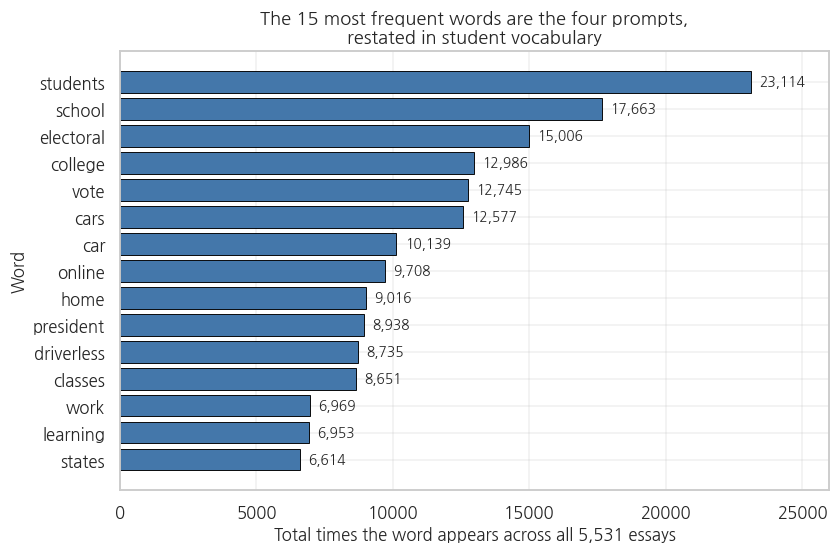

In [11]:
top15 = freq.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.barh(top15.index, top15.values, color=BLUE, edgecolor='black', linewidth=0.6)
ax.set_xlabel('Total times the word appears across all 5,531 essays')
ax.set_ylabel('Word')
ax.set_title('The 15 most frequent words are the four prompts,\nrestated in student vocabulary')
ax.set_xlim(0, 26000)
for y, v in enumerate(top15.values):
    ax.text(v + 300, y, f'{v:,}', va='center', fontsize=9)
plt.show()

**🧠 Interpret this chart.** Every word on this list is a noun from one of the four prompts: `students`, `school`, `electoral`, `college`, `vote`, `cars`, `car`, `online`, `home`, `president`. The frequency table has told you what the prompts were. It has told you nothing about what any student *argued*.

That is the normal outcome of a raw frequency count, and it is why frequency tables are a starting point rather than a finding. The interesting question is never "which words are common" but **"which words are unusually common *here* compared to everywhere else."** That is what the next cell computes.

In [12]:
def distinctive_words(prompt, n=8, min_count=60):
    'Words whose share of one prompt most exceeds their share of the whole corpus.'
    rows = np.where((essays['prompt_short'] == prompt).values)[0]
    prompt_counts = np.asarray(X_counts[rows].sum(axis=0)).ravel()
    prompt_share = prompt_counts / prompt_counts.sum()
    overall_share = totals / totals.sum()
    ratio = np.where(prompt_counts >= min_count, prompt_share / overall_share, 0)
    return ', '.join(vocab[np.argsort(ratio)[::-1][:n]])

distinct = pd.DataFrame({
    'prompt': list(PROMPT_SHORT.values()),
    'distinctive words (appearing at least 60 times)':
        [distinctive_words(p) for p in PROMPT_SHORT.values()],
})
print(distinct.to_string(index=False))
print()
print('A detail worth stopping on. Where four of these words actually live:')
cell_rows = essays['prompt_short'] == 'cell phones'
for w in ['principal', 'principle', 'alot', 'becuase']:
    n_all = int(totals[vocab == w][0]) if (vocab == w).any() else 0
    n_cell = int(essays.loc[cell_rows, 'clean']
                 .apply(lambda d, w=w: d.split().count(w)).sum())
    print(f'   {w:<12} {n_all:>6,} in the whole corpus, '
          f'{n_cell:>5,} of them inside the cell phone essays')

           prompt                                            distinctive words (appearing at least 60 times)
electoral college      senator, regional, invariably, republican, electors, democratic, governor, presidents
distance learning conferencing, illnesses, lectures, attended, enrolled, homeschooling, schooled, attendance
  driverless cars                    driverless, flashing, gm, tesla, manufactures, driveways, drunk, sensor
      cell phones                          policy, cell, principal, phones, principle, lunch, aloud, periods

A detail worth stopping on. Where four of these words actually live:
   principal       591 in the whole corpus,   570 of them inside the cell phone essays
   principle       164 in the whole corpus,   152 of them inside the cell phone essays
   alot            422 in the whole corpus,     4 of them inside the cell phone essays
   becuase         215 in the whole corpus,     0 of them inside the cell phone essays


**🧠 Interpret this table.** Cover the first column with your hand and try to name each prompt from its distinctive words alone. It is easy. `conferencing, illnesses, lectures, enrolled, homeschooling` is distance learning. `flashing, gm, tesla, sensor` is driverless cars.

Keep that feeling of easy confidence, because in Section 5 a topic model will hand you exactly this kind of list without the answer column, and you will have to name the topics yourself. **The confidence you feel right now is borrowed from the answer key.**

Now the detail at the bottom. `principal` appears 591 times in the corpus and 570 of those are in the cell phone essays. `principle` appears 164 times, 152 of them in the same place. These students were told to write a letter to their principal. A meaningful fraction wrote to their principle. The vectorizer has no idea these are the same intended word, and `principle` shows up in the distinctive-words list as though it were a concept in the essays rather than a spelling error.

You could fix that with a spellchecker. Before you do, ask what else the spellchecker would change, whose writing it would change most, and whether the thing you would be measuring afterward is still the thing the students wrote.

---

## 📊 4. A stance lexicon you can read in full

Most sentiment tools arrive as a black box you install. We are not doing that, for two reasons. The practical one: installs break, and a notebook that needs a download is a notebook that fails in a classroom. The real one: **you cannot critique a word list you have never seen.**

There is a second reason to change the instrument. "Sentiment" is a poor fit for argumentative writing. An essay arguing that driverless cars are dangerous will be full of `crash`, `accident`, and `danger` no matter how good the argument is, and a sentiment score will read the topic and call it the writer's mood. So we measure something closer to what actually varies in argument: **stance strength**.

- **Hedges** hold a claim loosely: `maybe`, `might`, `seems`, `probably`, `suggests`.
- **Boosters** assert a claim hard: `always`, `clearly`, `obviously`, `proves`, `definitely`.

Both are real features of academic argument, both are teachable, and rubrics disagree about which one they reward. Here is the entire lexicon. Fifty-two words, printed in plain sight, and every number in this section comes from these two lists and nothing else.

In [13]:
HEDGES = '''
maybe perhaps possibly probably might may could seems seem appears likely
somewhat arguably suggests suggest think believe sometimes often usually generally
tend tends unsure unclear roughly potentially
'''.split()

BOOSTERS = '''
always never definitely certainly obviously clearly absolutely must completely
totally undoubtedly proves prove proven fact facts truly everyone nobody impossible
essential crucial vital surely extremely
'''.split()

HEDGE_SET, BOOST_SET = set(HEDGES), set(BOOSTERS)

print(f'HEDGES   ({len(HEDGES)} words):')
print('  ', ', '.join(HEDGES))
print()
print(f'BOOSTERS ({len(BOOSTERS)} words):')
print('  ', ', '.join(BOOSTERS))
print()
print('That is the whole instrument. There is nothing else in it.')
print('If you disagree with a word, you can delete it, and you will in a moment.')

HEDGES   (27 words):
   maybe, perhaps, possibly, probably, might, may, could, seems, seem, appears, likely, somewhat, arguably, suggests, suggest, think, believe, sometimes, often, usually, generally, tend, tends, unsure, unclear, roughly, potentially

BOOSTERS (25 words):
   always, never, definitely, certainly, obviously, clearly, absolutely, must, completely, totally, undoubtedly, proves, prove, proven, fact, facts, truly, everyone, nobody, impossible, essential, crucial, vital, surely, extremely

That is the whole instrument. There is nothing else in it.
If you disagree with a word, you can delete it, and you will in a moment.


Now the scorer. Read it: it is eight lines and there is nothing hidden in it. We divide by essay length and multiply by 100, so the score is *hedges per hundred words*, not raw hedges. That matters enormously here, since essays range from 146 to 6,188 words.

In [14]:
def stance_rates(text):
    'Return hedges per 100 words and boosters per 100 words.'
    tokens = re.sub(r"[^a-z\s']", ' ', text.lower()).split()
    n = max(len(tokens), 1)
    hedge = sum(1 for t in tokens if t in HEDGE_SET)
    boost = sum(1 for t in tokens if t in BOOST_SET)
    return 100 * hedge / n, 100 * boost / n

rates = essays['full_text'].apply(
    lambda t: pd.Series(stance_rates(t), index=['hedge_rate', 'booster_rate']))
essays[['hedge_rate', 'booster_rate']] = rates

print('Stance rates, per 100 words:')
print(essays[['hedge_rate', 'booster_rate']].describe().round(3).to_string())
print()
print(f'Essays with no hedge at all     : {(essays["hedge_rate"] == 0).sum():,} '
      f'({(essays["hedge_rate"] == 0).mean():.1%})')
print(f'Essays with no booster at all   : {(essays["booster_rate"] == 0).sum():,} '
      f'({(essays["booster_rate"] == 0).mean():.1%})')
print(f'Essays the lexicon cannot see at all (neither): '
      f'{((essays["hedge_rate"] == 0) & (essays["booster_rate"] == 0)).sum():,} '
      f'({((essays["hedge_rate"] == 0) & (essays["booster_rate"] == 0)).mean():.1%})')
print()
print('Mean rates by the score a human gave the essay:')
by_score = essays.groupby('holistic_essay_score').agg(
    essays=('essay_id', 'size'),
    hedge_rate=('hedge_rate', 'mean'),
    booster_rate=('booster_rate', 'mean'),
    mean_words=('essay_word_count', 'mean'),
).round(3)
print(by_score.to_string())

Stance rates, per 100 words:
       hedge_rate  booster_rate
count    5531.000      5531.000
mean        1.328         0.361
std         0.963         0.393
min         0.000         0.000
25%         0.636         0.000
50%         1.136         0.277
75%         1.810         0.555
max        13.983         2.865

Essays with no hedge at all     : 245 (4.4%)
Essays with no booster at all   : 1,878 (34.0%)
Essays the lexicon cannot see at all (neither): 122 (2.2%)

Mean rates by the score a human gave the essay:
                      essays  hedge_rate  booster_rate  mean_words
holistic_essay_score                                              
1                        200       1.026         0.223     362.575
2                       1012       1.491         0.308     285.876
3                       1811       1.410         0.344     368.530
4                       1428       1.293         0.383     481.801
5                        799       1.173         0.440     644.453
6           

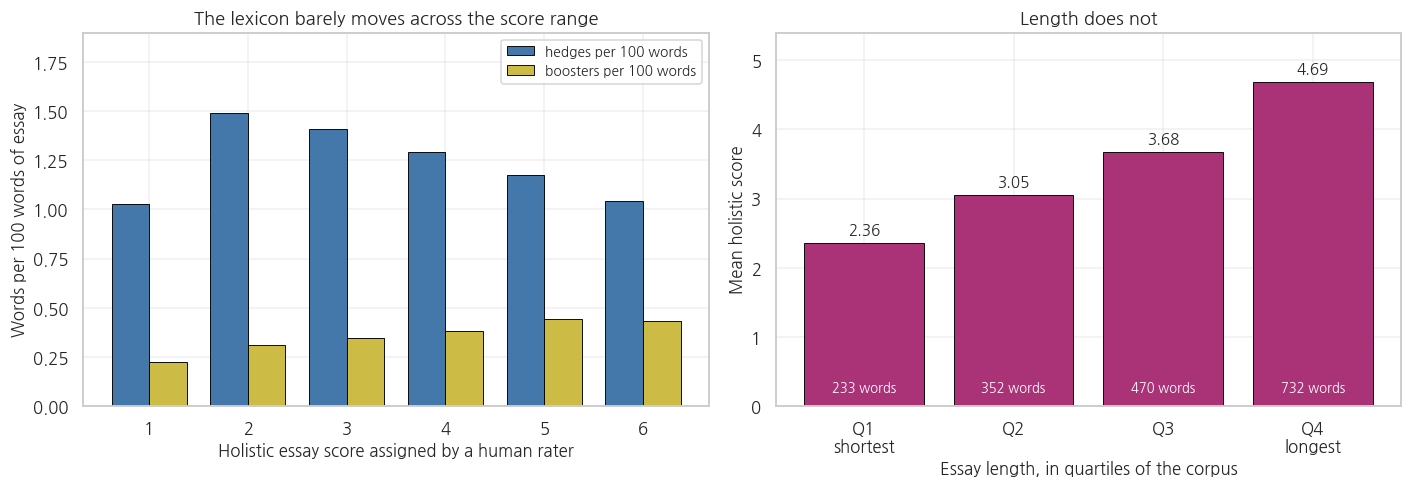

Essay length quartiles, which is what the right panel plots:
                n  mean_words  mean_score
wc_quartile                              
Q1 shortest  1384      233.48        2.36
Q2           1385      352.43        3.05
Q3           1381      469.50        3.68
Q4 longest   1381      731.62        4.69

Correlation with the human holistic score, computed two ways.
Two, because essay length is heavily right-skewed (146 to 6,188 words, median 406)
and the score is six ordered categories, not a continuous quantity. Pearson asks
whether a straight line fits the raw numbers. Spearman only asks whether the two
rankings move together, so a handful of very long essays cannot dominate it.

                                Pearson r  Spearman rho
   hedges per 100 words            -0.091        -0.067
   boosters per 100 words          +0.125        +0.187
   raw word count                  +0.559        +0.753


In [15]:
# Two panels: what the lexicon sees, and what a word count sees.
essays['wc_quartile'] = pd.qcut(essays['essay_word_count'], 4,
                                labels=['Q1\nshortest', 'Q2', 'Q3', 'Q4\nlongest'])
wc = essays.groupby('wc_quartile', observed=True).agg(
    n=('essay_id', 'size'),
    mean_words=('essay_word_count', 'mean'),
    mean_score=('holistic_essay_score', 'mean'),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

xs = by_score.index.values
w = 0.38
axes[0].bar(xs - w / 2, by_score['hedge_rate'], width=w, color=BLUE,
            edgecolor='black', linewidth=0.6, label='hedges per 100 words')
axes[0].bar(xs + w / 2, by_score['booster_rate'], width=w, color=YELLOW,
            edgecolor='black', linewidth=0.6, label='boosters per 100 words')
axes[0].set_xlabel('Holistic essay score assigned by a human rater')
axes[0].set_ylabel('Words per 100 words of essay')
axes[0].set_title('The lexicon barely moves across the score range')
axes[0].set_xticks(list(xs))
axes[0].set_ylim(0, 1.9)
axes[0].legend(fontsize=9)

axes[1].bar(range(len(wc)), wc['mean_score'], color=PURPLE,
            edgecolor='black', linewidth=0.6)
axes[1].set_xticks(range(len(wc)))
axes[1].set_xticklabels(wc.index)
axes[1].set_xlabel('Essay length, in quartiles of the corpus')
axes[1].set_ylabel('Mean holistic score')
axes[1].set_title('Length does not')
axes[1].set_ylim(0, 5.4)
for i, (v, mw) in enumerate(zip(wc['mean_score'], wc['mean_words'])):
    axes[1].text(i, v + 0.12, f'{v:.2f}', ha='center', fontsize=10)
    axes[1].text(i, 0.2, f'{mw:.0f} words', ha='center', fontsize=8.5, color='white')

plt.show()

print('Essay length quartiles, which is what the right panel plots:')
print(wc.rename(index=lambda s: str(s).replace(chr(10), ' ')).to_string())
print()
print('Correlation with the human holistic score, computed two ways.')
print('Two, because essay length is heavily right-skewed (146 to 6,188 words, median 406)')
print('and the score is six ordered categories, not a continuous quantity. Pearson asks')
print('whether a straight line fits the raw numbers. Spearman only asks whether the two')
print('rankings move together, so a handful of very long essays cannot dominate it.')
print()
print(f'   {"":<26}{"Pearson r":>12}{"Spearman rho":>14}')
for col, label in [('hedge_rate', 'hedges per 100 words'),
                   ('booster_rate', 'boosters per 100 words'),
                   ('essay_word_count', 'raw word count')]:
    r = essays[col].corr(essays['holistic_essay_score'])
    rho = essays[col].corr(essays['holistic_essay_score'], method='spearman')
    print(f'   {label:<26}{r:>+12.3f}{rho:>+14.3f}')

**🧠 Interpret this figure. It is the most uncomfortable result in the notebook so far.**

The lexicon you can read, built out of a real construct from the writing research literature, correlates with the human score at **r = -0.091** for hedges and **r = +0.125** for boosters. Look at the left panel: hedging peaks in the essays scored 2 (1.49 per 100 words) and falls steadily to 1.05 at score 6, except that the essays scored 1 are the least hedged of all at 1.03. So the relationship is not even monotonic, and the whole range is under half a word per hundred. That is not nothing. It is close to nothing.

The right panel is raw word count, which required no lexicon, no theory, and no judgment. It correlates with the human score at **r = +0.559**, and at **rho = +0.753** once you compare ranks instead of raw values. Both are in the printout, and the second is the one to quote: essay length runs from 146 to 6,188 words, so a few very long essays pull a Pearson correlation around, while a rank correlation cannot be pushed by them. The rank measure says the relationship is *stronger* than the Pearson number suggests, not weaker. (The two stance measures barely move under either: -0.091 and -0.067 for hedges, +0.125 and +0.187 for boosters.)

The shortest quarter of essays (mean 233 words) averages a score of **2.36**. The longest quarter (mean 732 words) averages **4.69**. That is a gap of more than two points on a six-point scale, produced by counting.

Sit with this before you explain it away, because there are at least three explanations and they have very different consequences:

1. **Longer essays are better essays.** Developing an argument takes words. Length is a real, if crude, proxy for elaboration.
2. **Raters reward length.** Under time pressure, a full page reads as effort, and rubrics that mention "development" invite that reading.
3. **Length is a proxy for something else**, such as typing speed, testing accommodations, or how much of the class period the student had left.

You cannot distinguish these with this file. What you *can* say is that any automated scorer trained on these labels will learn the length relationship first, because it is the strongest thing in the data. Hold that thought until Section 6.

And notice: **122 essays contain no word from either list.** For those essays the instrument returns 0.0 for both, which will be read downstream as "perfectly neutral stance." They are not neutral. They are unmeasured, and a mean cannot tell the difference.

### ✏️ Your turn 2: edit the lexicon and watch what does not happen

Below, `WORDS_TO_DROP` removes hedge words that are arguably not hedges at all. `think` and `believe` are the interesting fight: "I think phones should be banned" is a first-person assertion, not a qualification, and a lot of student writing uses `I think` as a sentence starter rather than as an epistemic marker.

The list ships with a working default, so run it untouched first. Then change it and re-run. Watch how much the correlation moves.

In [16]:
# TODO (optional): edit this list. Which of these are real hedges, and which
# are just how a fourteen-year-old starts a sentence?
WORDS_TO_DROP = ['think', 'believe', 'often', 'sometimes', 'usually', 'generally']

HEDGE_SET_V2 = HEDGE_SET - set(WORDS_TO_DROP)
print(f'Hedge lexicon: {len(HEDGE_SET)} words -> {len(HEDGE_SET_V2)} words')
print(f'Dropped: {", ".join(sorted(set(WORDS_TO_DROP) & HEDGE_SET))}')
print()

def hedge_v2(text):
    tokens = re.sub(r"[^a-z\s']", ' ', text.lower()).split()
    return 100 * sum(1 for t in tokens if t in HEDGE_SET_V2) / max(len(tokens), 1)

essays['hedge_rate_v2'] = essays['full_text'].apply(hedge_v2)

compare = essays.groupby('holistic_essay_score')[['hedge_rate', 'hedge_rate_v2']].mean().round(3)
compare['change'] = (compare['hedge_rate_v2'] - compare['hedge_rate']).round(3)
print('Mean hedge rate by human score, version 1 against version 2:')
print(compare.to_string())
print()
def both_correlations(col):
    return (essays[col].corr(essays['holistic_essay_score']),
            essays[col].corr(essays['holistic_essay_score'], method='spearman'))

print(f'{"Correlation with the human score":<38}{"Pearson r":>12}{"Spearman rho":>14}')
for col, label in [('hedge_rate', '  hedge lexicon, v1'),
                   ('hedge_rate_v2', '  hedge lexicon, v2'),
                   ('essay_word_count', '  raw word count, for comparison')]:
    r, rho = both_correlations(col)
    print(f'{label:<38}{r:>+12.3f}{rho:>+14.3f}')

Hedge lexicon: 27 words -> 21 words
Dropped: believe, generally, often, sometimes, think, usually



Mean hedge rate by human score, version 1 against version 2:
                      hedge_rate  hedge_rate_v2  change
holistic_essay_score                                   
1                          1.026          0.461  -0.565
2                          1.491          0.741  -0.750
3                          1.410          0.810  -0.600
4                          1.293          0.866  -0.427
5                          1.173          0.867  -0.306
6                          1.045          0.818  -0.227

Correlation with the human score         Pearson r  Spearman rho
  hedge lexicon, v1                         -0.091        -0.067
  hedge lexicon, v2                         +0.077        +0.141
  raw word count, for comparison            +0.559        +0.753


**🧠 Interpret this comparison. Look at the sign.**

Version 1 correlates with the human score at **r = -0.091**. Version 2, after deleting six words, correlates at **r = +0.077**. **The relationship changed direction.** It is not an artifact of which correlation you use: the rank version flips too, from **rho = -0.067** to **rho = +0.141**.

Neither correlation is strong enough to build anything on, and that is exactly what makes this dangerous. If you had published version 1 you would have written that stronger essays hedge less. If you had published version 2 you would have written that stronger essays hedge more. Same corpus, same construct, same defensible reasoning, six words.

The only defense against this is the one this notebook has been practicing: **print the word list.** A reader who can see your lexicon can check you. A reader who is handed "hedging was negatively associated with essay quality" cannot.

Meanwhile the raw word count is still sitting there at **r = +0.559**, unmoved by any of it. In Section 4 you have now seen both failure modes of lexicon work in one place: a measure that is easy to change and does not matter, sitting next to a measure that nobody would defend theoretically and matters a great deal.

Put a sentence about this in your memo. Which of the two would you report to a teacher, and which would you refuse to report, and why is that not the same question as which one is more accurate?

---

## 📊 5. Topic modeling: NMF and LDA, side by side

A topic model reads a pile of documents and proposes groups of words that tend to occur together. That is genuinely all it does. It does not know what a topic is, it cannot name anything, and it has never seen a writing prompt.

We fit two of them on the same 5,531 essays:

- **NMF** (Non-negative Matrix Factorization) is linear algebra. It factors the document-term matrix into two non-negative matrices and reads topics off one of them. It usually pairs with **TF-IDF** weighting, which downweights words that appear everywhere.
- **LDA** (Latent Dirichlet Allocation) is a probability model. It supposes every document is a mixture of topics and every topic is a distribution over words, then estimates both. It wants raw counts.

We have something rare here: **an answer key.** These essays answer four known prompts. So we can ask for four topics and check the models against the truth, which is a luxury you will almost never have. Watch what that luxury does to your judgment.

In [17]:
N_TOPICS = 4

# NMF wants TF-IDF weighting.
tfidf_vec = TfidfVectorizer(stop_words=MY_STOPWORDS, min_df=5, max_df=0.5)
X_tfidf = tfidf_vec.fit_transform(essays['clean'])
tfidf_vocab = np.array(tfidf_vec.get_feature_names_out())

nmf_model = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE,
                init='nndsvda', max_iter=400)
W_nmf = nmf_model.fit_transform(X_tfidf)

# LDA wants raw counts, which we already built in Section 3.
lda_model = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE,
                                      max_iter=20, learning_method='batch')
W_lda = lda_model.fit_transform(X_counts)

def top_words(model, feature_names, n=10):
    return [', '.join(feature_names[c.argsort()[-n:][::-1]]) for c in model.components_]

nmf_words = top_words(nmf_model, tfidf_vocab)
lda_words = top_words(lda_model, vocab)

side_by_side = pd.DataFrame({
    'k': range(N_TOPICS),
    'NMF topic (top 10 words)': nmf_words,
    'LDA topic (top 10 words)': lda_words,
})
print('Two models, four topics each, same corpus:')
print(side_by_side.to_string(index=False))

Two models, four topics each, same corpus:
 k                                                               NMF topic (top 10 words)                                                               LDA topic (top 10 words)
 0 electoral, vote, college, president, electors, votes, states, popular, election, state electoral, vote, college, president, states, electors, votes, popular, state, election
 1      students, school, online, classes, home, learning, work, student, distance, learn         students, school, online, classes, home, learning, work, student, class, learn
 2        cars, car, driverless, driver, driving, drive, technology, road, human, drivers               phones, school, cell, students, phone, use, class, policy, student, free
 3                 phones, cell, school, phone, policy, students, use, class, lunch, free           cars, car, driverless, driver, driving, drive, technology, make, human, road


**🧠 Interpret these word lists before you look at any chart.** Cover the rest of the notebook and name all eight topics from the words alone. You can do it in about fifteen seconds, and both models found the same four things.

Notice what you just did. You did not name those topics from the word lists. You recognized them, because you read the prompt table in Section 1 and you already knew what the four answers were. That is not interpretation, it is recall. The next cell checks whether your recognition was right.

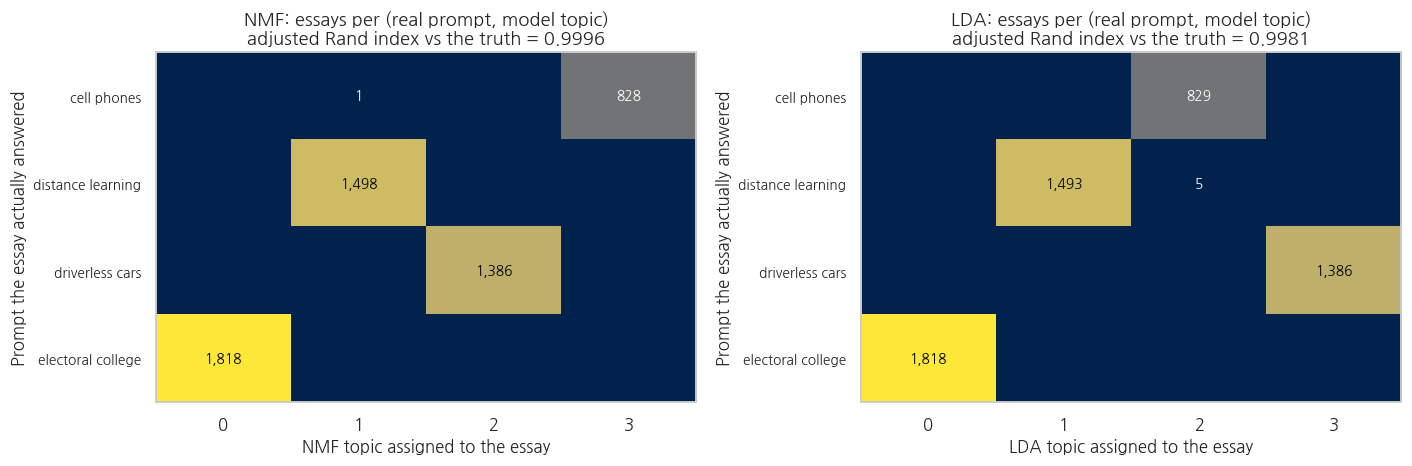

Essays NMF filed under a topic that is not its prompt's main topic : 1 of 5,531
Essays LDA filed under a topic that is not its prompt's main topic : 5 of 5,531
Adjusted Rand index against the real prompts, NMF                 : 0.9996
Adjusted Rand index against the real prompts, LDA                 : 0.9981
Agreement between the two models (adjusted Rand index)             : 0.9977


In [18]:
essays['nmf_topic'] = W_nmf.argmax(axis=1)
essays['lda_topic'] = W_lda.argmax(axis=1)

ct_nmf = pd.crosstab(essays['prompt_short'], essays['nmf_topic'])
ct_lda = pd.crosstab(essays['prompt_short'], essays['lda_topic'])

ari_nmf = adjusted_rand_score(essays['prompt_short'], essays['nmf_topic'])
ari_lda = adjusted_rand_score(essays['prompt_short'], essays['lda_topic'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, ct, name in zip(axes, [ct_nmf, ct_lda], ['NMF', 'LDA']):
    ax.imshow(ct.values, cmap='cividis', aspect='auto')
    ax.set_xticks(range(ct.shape[1]))
    ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(ct.shape[0]))
    ax.set_yticklabels(ct.index, fontsize=9)
    ax.set_xlabel(f'{name} topic assigned to the essay')
    ax.set_ylabel('Prompt the essay actually answered')
    ari = ari_nmf if name == 'NMF' else ari_lda
    ax.set_title(f'{name}: essays per (real prompt, model topic)\n'
                 f'adjusted Rand index vs the truth = {ari:.4f}')
    ax.grid(False)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            v = ct.values[i, j]
            if v > 0:
                ax.text(j, i, f'{v:,}', ha='center', va='center', fontsize=9,
                        color='white' if v < ct.values.max() * 0.5 else 'black')
plt.show()

off_nmf = int(ct_nmf.values.sum() - ct_nmf.values.max(axis=1).sum())
off_lda = int(ct_lda.values.sum() - ct_lda.values.max(axis=1).sum())
print(f'Essays NMF filed under a topic that is not its prompt\'s main topic : {off_nmf} of {len(essays):,}')
print(f'Essays LDA filed under a topic that is not its prompt\'s main topic : {off_lda} of {len(essays):,}')
print(f'Adjusted Rand index against the real prompts, NMF                 : {ari_nmf:.4f}')
print(f'Adjusted Rand index against the real prompts, LDA                 : {ari_lda:.4f}')
print(f'Agreement between the two models (adjusted Rand index)             : '
      f'{adjusted_rand_score(essays["nmf_topic"], essays["lda_topic"]):.4f}')

**🧠 Interpret these two heatmaps, and then be suspicious of them.**

Both models nailed it. NMF misplaces **1 essay out of 5,531** (adjusted Rand index 0.9996). LDA misplaces **5** (0.9981). The two models agree with each other at 0.9977. In week 5 of a synthetic-data course this would be the happy ending.

It is not a happy ending. It is the easiest possible version of the task, and you set it up that way without noticing:

- You **knew there were four groups**, so you asked for four. In real corpus work the number of topics is the hardest decision you make and there is no answer key to check it against.
- The four groups are about **completely unrelated subjects**. Cars, phones, voting, and online school share almost no vocabulary. Any method that counts words would separate them, including sorting essays by whether they contain the word "car."
- The thing the model recovered, **which prompt an essay answers, is already in the file.** You did not learn anything you did not have.

**A topic model that reproduces a variable you already have has demonstrated that it works, not that it is useful.** The useful question is what happens when you ask for structure the file does not already record. That is the next cell, and it gets more interesting.

### ✏️ Your turn 3: ask for more topics than there are prompts

`N_TOPICS = 4` was not discovered, it was assumed. Change `N_TOPICS_TRY` below and see what the model does when you ask it for a number the answer key cannot confirm. It runs with 8 as written, which splits each prompt roughly in half.

Watch for two things. First, the model will always give you exactly the number of topics you ask for and will never tell you the number was wrong. Second, look hard at the composition table underneath. The sub-topics are not sub-subjects.

In [19]:
# TODO (optional): try 8, then 3, then 12. What happens to the word lists?
N_TOPICS_TRY = 8

trial = NMF(n_components=N_TOPICS_TRY, random_state=RANDOM_STATE,
            init='nndsvda', max_iter=400).fit(X_tfidf)
trial_assign = trial.transform(X_tfidf).argmax(axis=1)

print(f'NMF with {N_TOPICS_TRY} topics:\n')
for i, words in enumerate(top_words(trial, tfidf_vocab, n=9)):
    print(f'  topic {i}: {words}')
print()
print('Prompts folded into each topic (count of essays):')
print(pd.crosstab(essays['prompt_short'], trial_assign).to_string())
print()
print(f'Adjusted Rand index against the real prompts: '
      f'{adjusted_rand_score(essays["prompt_short"], trial_assign):.3f} '
      f'(it was {ari_nmf:.4f} at four topics)')
print()

# Zoom in on one prompt, and look at who ends up in each sub-topic.
essays['trial_topic'] = trial_assign
zoom = essays[(essays['prompt_short'] == 'distance learning') &
              (essays['ell_status'].isin(['Yes', 'No']))]
profile = zoom.groupby('trial_topic').agg(
    essays=('essay_id', 'size'),
    mean_score=('holistic_essay_score', 'mean'),
    mean_words=('essay_word_count', 'mean'),
    pct_ELL=('ell_status', lambda s: 100 * (s == 'Yes').mean()),
).round({'mean_score': 2, 'mean_words': 1, 'pct_ELL': 1})
profile = profile[profile['essays'] >= 30].sort_values('pct_ELL')
print('Inside the distance learning prompt alone, who lands in each sub-topic:')
print(profile.to_string())

NMF with 8 topics:

  topic 0: electoral, college, votes, states, president, election, popular, candidate, state
  topic 1: online, classes, students, class, home, attend, taking, benefit, work
  topic 2: cars, driverless, driver, technology, driving, human, drivers, future, accidents
  topic 3: phones, cell, policy, phone, use, students, class, lunch, free
  topic 4: students, learning, distance, home, learn, student, education, schools, classroom
  topic 5: vote, president, electors, voting, popular, state, electoral, voters, election
  topic 6: car, driver, drive, driving, driveless, road, self, driverless, accident
  topic 7: school, home, kids, work, student, parents, help, don, need

Prompts folded into each topic (count of essays):
col_0                0    1    2    3    4     5    6    7
prompt_short                                              
cell phones          0    0    0  773    5     0    0   51
distance learning    0  507    0    0  608     0    0  383
driverless cars

**🧠 Interpret that last table. This is the part worth the whole section.**

At eight topics NMF splits each prompt into sub-topics, and the adjusted Rand index against the prompts drops to 0.595 because there is no longer a one-to-one mapping. Fine. Expected.

Now look inside the distance learning prompt. The model split those 1,498 essays into three groups using nothing but word counts, and the three groups have **almost identical average length** (604, 578, and 572 words, listed in the order of the bullets below) but very different composition:

- one sub-topic is **12.7 percent** English language learners and averages a score of **4.69**
- one is **27.9 percent** and averages **4.18**
- one is **37.5 percent** and averages **4.25**

Nobody gave the model an ELL column. It never saw a demographic variable. It was given words, and it sorted essays in a way that partly recovers who wrote them.

That is not mysticism, it is the ordinary consequence of the fact that groups of people write differently, and it is exactly why "we did not use race or language status as a feature" is not a defense of a text model. **A model trained on language has access to language, and language carries the writer.** Hold that sentence. Section 7 is built on it.

---

## 📊 6. The step synthetic data could never support: human ground truth

Everything up to here you could have done on invented text. Sections 2 through 5 measured properties of documents and compared them to each other. Nothing checked whether any of it corresponded to a human judgment, because in a simulated corpus there is no human judgment to check against. There is only the generator, and the generator agrees with you by construction.

This corpus is different. **Human beings read every one of these essays and marked, span by span, what each piece of the argument was doing.** Then they rated how well it did it.

The scheme has seven moves:

| Move | What the annotator was marking |
|---|---|
| `Lead` | an opening that pulls the reader in before the argument starts |
| `Position` | the writer's own stance on the question |
| `Claim` | a reason supporting the position |
| `Counterclaim` | a reason someone on the *other* side would give |
| `Rebuttal` | the writer's answer to a counterclaim |
| `Evidence` | facts, examples, or source material backing a claim |
| `Concluding Statement` | the close |

Plus `Unannotated`, which is text the annotators did not assign to any move.

And every marked span carries **Effective, Adequate, or Ineffective**.

This is what "ground truth" actually means, and it is worth naming what it is not. It is not the truth about the writing. It is **a record of what trained human raters decided**, made under a rubric, at a certain pace, for a certain fee. Every model you fit against it learns those decisions, including anything systematically wrong with them. Section 7 is about exactly that.

In [20]:
print('SPANS: the human annotation layer')
print(f'  total spans                 : {len(spans):,}')
print(f'  marked "Unannotated"        : {(spans["discourse_type"] == "Unannotated").sum():,} '
      f'({(spans["discourse_type"] == "Unannotated").mean():.1%} of spans)')
print(f'  missing an effectiveness rating : {spans["discourse_effectiveness"].isna().sum():,}')
print()
print('Which spans have no effectiveness rating?')
print(spans[spans['discourse_effectiveness'].isna()]['discourse_type']
      .value_counts().to_string())
print()
print('So: the unrated spans are the Unannotated ones, plus exactly two others')
print('that slipped through. Two rows out of 63,211. We drop them and say so.')
print()

# The decision, stated: keep spans that have both a real type and a rating.
rated = spans[(spans['discourse_type'] != 'Unannotated') &
              (spans['discourse_effectiveness'].notna())].copy()
rated['n_words'] = rated['discourse_text'].str.split().str.len()
print(f'Working set for this section: {len(rated):,} spans '
      f'(dropped {len(spans) - len(rated):,}: {(spans["discourse_type"] == "Unannotated").sum():,} '
      f'Unannotated plus 2 unrated).')
print()
print('What that drop costs: the Unannotated spans are 12.9 percent of the corpus,')
print('and they are the text the annotators did not think was doing argumentative')
print('work. Any claim we make below is a claim about the parts of these essays')
print('that a human recognised as argument.')
print()

profile = rated.groupby('discourse_type').agg(
    spans=('essay_id', 'size'),
    mean_words=('n_words', 'mean'),
    median_words=('n_words', 'median'),
).round(1).sort_values('spans', ascending=False)
print(profile.to_string())
print()
print('How the humans rated them, overall:')
print((rated['discourse_effectiveness'].value_counts(normalize=True) * 100).round(1).to_string())

SPANS: the human annotation layer
  total spans                 : 63,211
  marked "Unannotated"        : 8,141 (12.9% of spans)
  missing an effectiveness rating : 8,143

Which spans have no effectiveness rating?
discourse_type
Unannotated    8141
Position          1
Lead              1

So: the unrated spans are the Unannotated ones, plus exactly two others
that slipped through. Two rows out of 63,211. We drop them and say so.

Working set for this section: 55,068 spans (dropped 8,143: 8,141 Unannotated plus 2 unrated).

What that drop costs: the Unannotated spans are 12.9 percent of the corpus,
and they are the text the annotators did not think was doing argumentative
work. Any claim we make below is a claim about the parts of these essays
that a human recognised as argument.

                      spans  mean_words  median_words
discourse_type                                       
Claim                 19200        18.4          16.0
Evidence              16888        76.4         

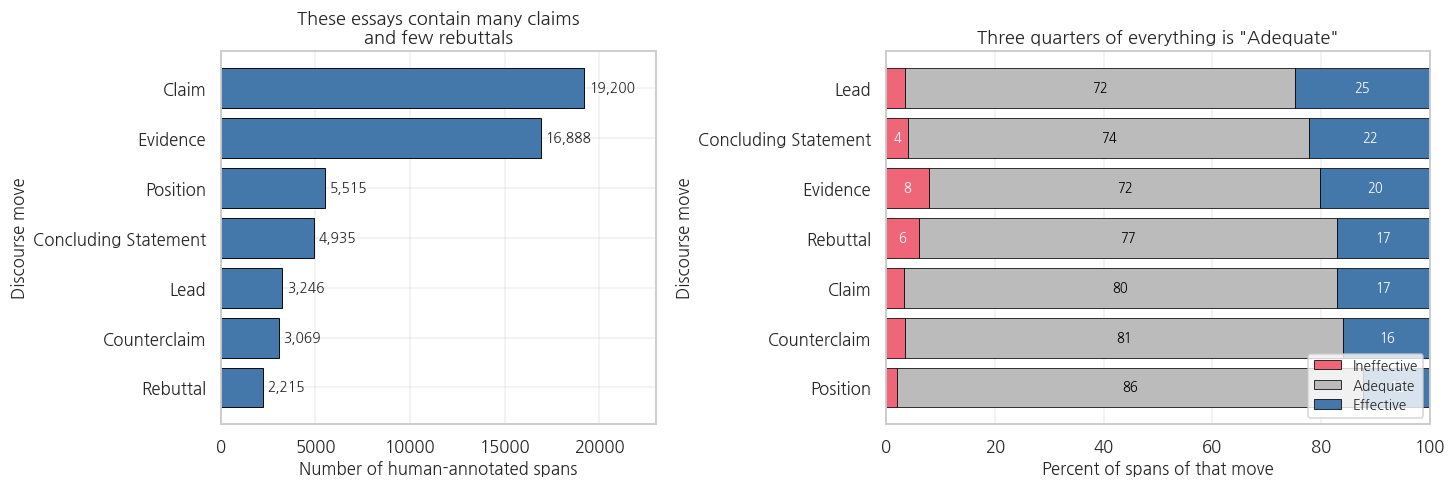

The right panel as a table, because the percentages matter to one decimal:
discourse_effectiveness  Ineffective  Adequate  Effective
discourse_type                                           
Position                         2.0      85.7       12.3
Counterclaim                     3.5      80.5       16.0
Claim                            3.3      79.5       17.2
Rebuttal                         6.0      76.7       17.2
Evidence                         8.0      71.7       20.3
Concluding Statement             4.1      73.6       22.2
Lead                             3.5      71.5       24.9

Claims per rebuttal in this corpus: 8.7 (19,200 claims, 2,215 rebuttals)


In [21]:
eff_by_type = pd.crosstab(rated['discourse_type'], rated['discourse_effectiveness'],
                          normalize='index')[['Ineffective', 'Adequate', 'Effective']] * 100
eff_by_type = eff_by_type.sort_values('Effective')
n_by_type = rated['discourse_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6), gridspec_kw={'width_ratios': [1, 1.25]})

order = n_by_type.sort_values().index
axes[0].barh(order, n_by_type[order].values, color=BLUE, edgecolor='black', linewidth=0.6)
for y, v in enumerate(n_by_type[order].values):
    axes[0].text(v + 250, y, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Number of human-annotated spans')
axes[0].set_ylabel('Discourse move')
axes[0].set_title('These essays contain many claims\nand few rebuttals')
axes[0].set_xlim(0, 23000)

left = np.zeros(len(eff_by_type))
for col, colr in [('Ineffective', ROSE), ('Adequate', GREY), ('Effective', BLUE)]:
    axes[1].barh(eff_by_type.index, eff_by_type[col], left=left, color=colr,
                 edgecolor='black', linewidth=0.5, label=col)
    for y, (v, l) in enumerate(zip(eff_by_type[col], left)):
        if v > 4:
            axes[1].text(l + v / 2, y, f'{v:.0f}', ha='center', va='center',
                         fontsize=8.5, color='white' if col != 'Adequate' else 'black')
    left = left + eff_by_type[col].values
axes[1].set_xlabel('Percent of spans of that move')
axes[1].set_ylabel('Discourse move')
axes[1].set_title('Three quarters of everything is "Adequate"')
axes[1].set_xlim(0, 100)
axes[1].legend(fontsize=9, loc='lower right')
plt.show()

print('The right panel as a table, because the percentages matter to one decimal:')
print(eff_by_type.round(1).to_string())
print()
print(f'Claims per rebuttal in this corpus: '
      f'{n_by_type["Claim"] / n_by_type["Rebuttal"]:.1f} '
      f'({n_by_type["Claim"]:,} claims, {n_by_type["Rebuttal"]:,} rebuttals)')

**🧠 Interpret this figure.** Three things.

**The moves are wildly unequal in supply.** 19,200 claims against 2,215 rebuttals, which is **8.7 claims for every rebuttal** in this corpus. Before you read that as a fact about young writers, notice what produced it. These are single-sitting assessment essays answering a prompt that asked for a position and reasons. A rebuttal costs the writer two extra moves, stating the objection and then answering it, and none of these four prompts asked for one. The ratio is a property of a genre, a prompt, and a clock at least as much as of the people who did the writing.

**The rating scale is not really three categories.** 76.7 percent of all spans are Adequate, 18.5 percent Effective, 4.8 percent Ineffective. A scale where three quarters of the mass sits in the middle category has less resolution than it advertises, exactly like the holistic score in Section 1. Notice that this is the second time you have seen this and that it is a property of *rating under time pressure*, not of these particular raters.

**`Evidence` is the move raters mark down most often.** Its Ineffective rate is 8.0 percent, four times Position's 2.0. Its Effective rate, 20.3 percent, is third, behind `Lead` at 24.9 and `Concluding Statement` at 22.2. Position, by contrast, draws the middle category more than any other move: 85.7 percent of Position spans are called Adequate.

Before you read that column as a ranking of moves, put it beside the length column in the table above. The three moves with the highest Effective rates, `Lead`, `Concluding Statement`, and `Evidence`, are also the three longest, at 52, 61, and 76 words against 18 for a `Claim`. Section 6 puts a number on that.

Write one sentence for your memo: if you built a feedback tool from this table alone, what would it tell a student to do more of, and would that advice be good?

### Now build a classifier, and check it against the humans

Here is the move that the synthetic data of weeks 1 through 4 could not support. We are going to train a model to predict **what kind of argumentative move a span is**, using nothing but the words in that span, and then check its answers against what a human annotator decided.

Not against our own intuition. Against 13,767 human judgments the model has never seen.

The model is deliberately plain: **a bag of words fed to multinomial naive Bayes.** Count how often each word appears in each class, apply Bayes' rule, predict the most probable class. There is no deep learning here, no embedding, no context. That is the point. When it fails you will be able to see exactly why.

One honest note about the split, followed by a check of it. We split spans at random, which means spans from the *same essay* land on both sides. With about eleven spans per essay that is not an edge case, it happens to essentially every essay in the test set, and the worry is real: the model could learn one student's phrasing in training and meet it again in testing. The stricter design splits by **essay**, so no essay appears on both sides.

The usual move at this point is to write "this probably overstates performance" and carry on. We are not going to, because that is a claim and claims get checked. The next cell fits the same model both ways and prints both numbers, so you can see what the leak is actually worth here rather than taking our word for it.

In [22]:
train, test = train_test_split(rated, test_size=0.25, random_state=RANDOM_STATE,
                               stratify=rated['discourse_type'])

# Note: the RAW span text, not the cleaned column. Section 2 explained why.
span_vec = CountVectorizer(min_df=3, max_features=20000)
X_train = span_vec.fit_transform(train['discourse_text'])
X_test = span_vec.transform(test['discourse_text'])

clf = MultinomialNB(alpha=0.3)
clf.fit(X_train, train['discourse_type'])
pred = clf.predict(X_test)

majority = train['discourse_type'].value_counts().idxmax()
baseline = (test['discourse_type'] == majority).mean()

print(f'Training spans : {len(train):,}')
print(f'Testing spans  : {len(test):,}')
print(f'Vocabulary     : {X_train.shape[1]:,} words')
print()
print(f'Accuracy                              : '
      f'{accuracy_score(test["discourse_type"], pred):.4f}')
print(f'Always guessing "{majority}" would give : {baseline:.4f}')
print(f'Macro F1 (treats every move as equally important) : '
      f'{f1_score(test["discourse_type"], pred, average="macro"):.4f}')
print()
print('Per-move report. Read the recall column, not the accuracy:')
print(classification_report(test['discourse_type'], pred, digits=3, zero_division=0))

# --- the check promised above: is the random span split flattering the model? ---
# GroupShuffleSplit keeps every span from one essay on the same side of the line.
strict_i, strict_j = next(GroupShuffleSplit(n_splits=1, test_size=0.25,
                                            random_state=RANDOM_STATE)
                          .split(rated, groups=rated['essay_id']))
strict_train, strict_test = rated.iloc[strict_i], rated.iloc[strict_j]
strict_vec = CountVectorizer(min_df=3, max_features=20000)
S_train = strict_vec.fit_transform(strict_train['discourse_text'])
S_test = strict_vec.transform(strict_test['discourse_text'])
strict_pred = (MultinomialNB(alpha=0.3)
               .fit(S_train, strict_train['discourse_type'])
               .predict(S_test))

print('IS THE RANDOM SPAN SPLIT FLATTERING THE MODEL?')
print(f'  test spans whose essay also supplied training spans, random span split : '
      f'{test["essay_id"].isin(set(train["essay_id"])).mean():.1%}')
print(f'  the same, once the split is made by essay                             : '
      f'{strict_test["essay_id"].isin(set(strict_train["essay_id"])).mean():.1%}')
print(f'  accuracy, random span split : '
      f'{accuracy_score(test["discourse_type"], pred):.4f}')
print(f'  accuracy, split by essay    : '
      f'{accuracy_score(strict_test["discourse_type"], strict_pred):.4f}')
print('  A leak you can name is not the same as a leak that matters. Read the two')
print('  accuracies before you decide which one this is.')

Training spans : 41,301
Testing spans  : 13,767
Vocabulary     : 8,692 words

Accuracy                              : 0.5472
Always guessing "Claim" would give : 0.3487
Macro F1 (treats every move as equally important) : 0.4609

Per-move report. Read the recall column, not the accuracy:
                      precision    recall  f1-score   support

               Claim      0.619     0.563     0.590      4800
Concluding Statement      0.397     0.498     0.442      1234
        Counterclaim      0.332     0.343     0.337       767
            Evidence      0.610     0.611     0.610      4222
                Lead      0.403     0.476     0.436       811
            Position      0.569     0.656     0.609      1379
            Rebuttal      0.294     0.153     0.202       554

            accuracy                          0.547     13767
           macro avg      0.461     0.471     0.461     13767
        weighted avg      0.550     0.547     0.546     13767



IS THE RANDOM SPAN SPLIT FLATTERING THE MODEL?
  test spans whose essay also supplied training spans, random span split : 99.9%
  the same, once the split is made by essay                             : 0.0%
  accuracy, random span split : 0.5472
  accuracy, split by essay    : 0.5644
  A leak you can name is not the same as a leak that matters. Read the two
  accuracies before you decide which one this is.


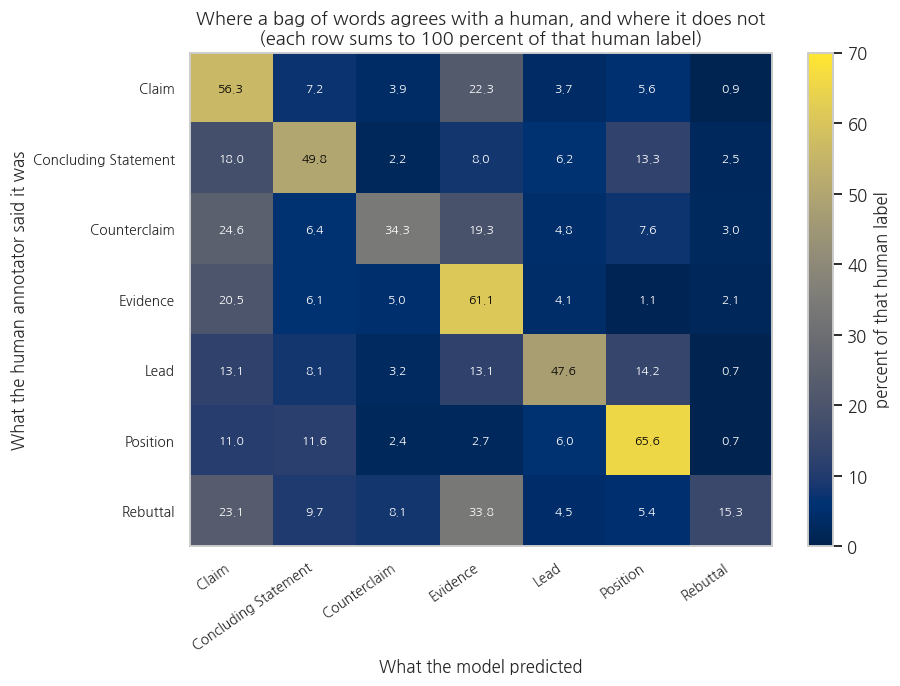

In [23]:
cm = pd.crosstab(test['discourse_type'], pred, normalize='index') * 100
labels = list(cm.index)
cm = cm.reindex(columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8.6, 6.4))
im = ax.imshow(cm.values, cmap='cividis', aspect='auto', vmin=0, vmax=70)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('What the model predicted')
ax.set_ylabel('What the human annotator said it was')
ax.set_title('Where a bag of words agrees with a human, and where it does not\n'
             '(each row sums to 100 percent of that human label)')
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                color='white' if v < 35 else 'black')
fig.colorbar(im, ax=ax, label='percent of that human label')
plt.show()

**🧠 Interpret this confusion matrix. The diagonal is not the interesting part.**

Overall accuracy is **54.7 percent** against a majority-class baseline of **34.9 percent**. So the model learned something real. Now read the rows, because the average hides everything that matters.

- **Position: 65.6 percent correct.** The easiest move. Students signal their position with a small, repeatable vocabulary (`I believe`, `in my opinion`, `dear principal`), and a word counter finds it.
- **Evidence: 61.1 percent correct.** Also easy, for a duller reason: Evidence spans average 76 words against 18 for a Claim. The model is partly detecting *length*.
- **Counterclaim: 34.3 percent correct.** Almost a quarter of real counterclaims get called Claims.
- **Rebuttal: 15.3 percent correct.** The model gets it right roughly one time in seven. **33.8 percent of real rebuttals are labeled Evidence** and 23.1 percent are labeled Claim.

The two moves the model cannot see are the two that make an argument argumentative. That is not a coincidence, and the next cell shows why.

In [24]:
test = test.copy()
test['pred'] = pred

print('=== REAL REBUTTALS THAT THE MODEL CALLED EVIDENCE ===')
print(f'({int(((test["discourse_type"] == "Rebuttal") & (test["pred"] == "Evidence")).sum())} '
      f'of the {int((test["discourse_type"] == "Rebuttal").sum())} rebuttals in the test set)\n')
missed = test[(test['discourse_type'] == 'Rebuttal') & (test['pred'] == 'Evidence')]
for _, r in missed.sample(3, random_state=1).iterrows():
    print(f'  [human said: Rebuttal, {r["discourse_effectiveness"]} | model said: Evidence]')
    print('   ', r['discourse_text'].strip()[:330])
    print()

print('=== REBUTTALS THE MODEL GOT RIGHT, FOR CONTRAST ===\n')
hit = test[(test['discourse_type'] == 'Rebuttal') & (test['pred'] == 'Rebuttal')]
for _, r in hit.sample(2, random_state=1).iterrows():
    print('   ', r['discourse_text'].strip()[:240])
    print()

print('=== REAL COUNTERCLAIMS THAT THE MODEL CALLED CLAIMS ===\n')
cc = test[(test['discourse_type'] == 'Counterclaim') & (test['pred'] == 'Claim')]
for _, r in cc.sample(2, random_state=1).iterrows():
    print('   ', r['discourse_text'].strip()[:280])
    print()

=== REAL REBUTTALS THAT THE MODEL CALLED EVIDENCE ===
(187 of the 554 rebuttals in the test set)

  [human said: Rebuttal, Effective | model said: Evidence]
    but according to history things can happen such as in the 2000 election. Why keep a process that the majority of the citizens of this country don't want and a process that just causes issues.

  [human said: Rebuttal, Ineffective | model said: Evidence]
    with that being said with the presidents trying to run for president the will actually try to reach the peoples needs to meet there satisfactory. the swing states is sayiong that there one state isnt going to decide the whole election.

  [human said: Rebuttal, Effective | model said: Evidence]
    Consequently, this allows those who participate in after-school related activites to be scouted out easier instead of those who are doing non-school sanctioned events.

=== REBUTTALS THE MODEL GOT RIGHT, FOR CONTRAST ===

    but thats not tru according to the

Electoral College .

**🧠 Interpret what you just read. This is the diagnosis, and it is precise.**

Look at the rebuttals the model got **right**. They contain explicit repair vocabulary: "Although, this is incorrect because...", "but thats not tru according to...". The word `incorrect` is in the span. A word counter can find `incorrect`.

Now look at the rebuttals it **missed**. They answer an objection by citing something: "but according to history things can happen such as in the 2000 election." As a bag of words that is a historical reference, which is what Evidence looks like. The span *is* doing rebuttal work, and the work is invisible at the span level because **the thing that makes it a rebuttal is the counterclaim it answers, which is in a different row of the table.**

The counterclaims the model calls Claims are the same problem from the other side. "Distance learning could also not benefit you because some students wold not take it serously" is only a counterclaim if the essay argues *for* distance learning. If the essay argues against it, that identical sentence is a claim. **The label depends on the essay's position, and we handed the model a sentence with no essay attached.**

So the failure is not that naive Bayes is weak. The failure is that we asked a span-level model to predict a relational property. Counterclaim and Rebuttal are defined by their relationship to other moves. Position, Evidence, and Concluding Statement are defined by their own content, and those are exactly the three the model handles best.

This is the concrete version of what **Dowell and Kovanović** argue about modeling educational discourse: discourse is structured and social, and a representation that discards structure cannot recover it no matter how much data you feed it. Name this in your memo.

### ✏️ Your turn 4: swap the model, and classify a sentence you wrote

Two small jobs, both with working defaults.

First, `USE_LOGISTIC` swaps naive Bayes for logistic regression, a stronger linear model on the same features. It ships as `True`. Watch which numbers move and which do not.

Second, `MY_SENTENCES` is a short list of sentences for the model to label. It ships with four, one of each kind. Replace them with your own and see whether the model agrees with you. (This cell takes about five seconds because logistic regression on 41,301 spans is slower than naive Bayes.)

In [25]:
# TODO 1 (optional): set to False to compare against naive Bayes again.
USE_LOGISTIC = True

# TODO 2 (optional): replace these with sentences of your own.
MY_SENTENCES = [
    "I believe that cell phones should be allowed at school.",
    "Some people would argue that phones are too distracting in class.",
    "However, that argument ignores the fact that teachers can collect phones during tests.",
    "In a 2019 survey, 73 percent of teachers reported using phones for classwork.",
]

# max_iter=1000 because lbfgs needs about 480 passes on this matrix. At the
# scikit-learn default of 100, or at 400, it stops early and warns.
model2 = (LogisticRegression(max_iter=1000) if USE_LOGISTIC else MultinomialNB(alpha=0.3))
model2.fit(X_train, train['discourse_type'])
pred2 = model2.predict(X_test)

name = 'Logistic regression' if USE_LOGISTIC else 'Multinomial naive Bayes'
print(f'{name}')
print(f'  accuracy : {accuracy_score(test["discourse_type"], pred2):.4f} '
      f'(naive Bayes got {accuracy_score(test["discourse_type"], pred):.4f})')
print(f'  macro F1 : {f1_score(test["discourse_type"], pred2, average="macro"):.4f} '
      f'(naive Bayes got {f1_score(test["discourse_type"], pred, average="macro"):.4f})')
print()
per_class = pd.DataFrame({
    'naive Bayes recall': recall_score(test['discourse_type'], pred, average=None,
                                       labels=sorted(rated['discourse_type'].unique())),
    'this model recall': recall_score(test['discourse_type'], pred2, average=None,
                                      labels=sorted(rated['discourse_type'].unique())),
}, index=sorted(rated['discourse_type'].unique())).round(3)
per_class['change'] = (per_class['this model recall'] - per_class['naive Bayes recall']).round(3)
print(per_class.to_string())
print()
print('=== YOUR SENTENCES ===')
for s, p in zip(MY_SENTENCES, model2.predict(span_vec.transform(MY_SENTENCES))):
    print(f'  model says {p:<22} <- "{s}"')

Logistic regression
  accuracy : 0.6798 (naive Bayes got 0.5472)
  macro F1 : 0.5625 (naive Bayes got 0.4609)

                      naive Bayes recall  this model recall  change
Claim                              0.563              0.825   0.262
Concluding Statement               0.498              0.551   0.053
Counterclaim                       0.343              0.318  -0.025
Evidence                           0.611              0.732   0.121
Lead                               0.476              0.448  -0.028
Position                           0.656              0.634  -0.022
Rebuttal                           0.153              0.265   0.112

=== YOUR SENTENCES ===
  model says Position               <- "I believe that cell phones should be allowed at school."
  model says Counterclaim           <- "Some people would argue that phones are too distracting in class."
  model says Counterclaim           <- "However, that argument ignores the fact that teachers can collect phones duri

**🧠 Interpret the comparison.** Logistic regression is a genuinely better model here: accuracy climbs from **0.547 to 0.680** and macro F1 from **0.4609 to 0.5625**. Claim recall goes from 0.563 to 0.825 and Evidence from 0.611 to 0.732.

And Rebuttal goes from **0.153 to 0.265**. Use the right yardstick on that number: this is a seven-way choice, not a two-way one, so uniform guessing sits near 0.14 and the majority-class rule (always say Claim) scores 0 on Rebuttal. Recall of 0.265 is genuinely above chance and still means the model misses about three of every four rebuttals a human marked. Counterclaim goes from 0.343 to 0.318, which is to say **it got slightly worse.**

That is the finding. A stronger algorithm on the same features improved the moves that were already working and left the two hard moves roughly where they were. **When a better model does not fix a failure, the failure is in the representation, not the algorithm.** You would not have learned that from the accuracy number alone, which went up by thirteen points and looked like progress.

Now look at your four sentences. Did the model call the counterclaim a counterclaim? Most people find it calls at least one of these something else. Write down which one it missed, and whether *you* could have told them apart with the essay removed.

### The harder question: can it predict whether a move *worked*?

Predicting the move type is a description task. The task with consequences is the other one: given a span, predict whether a human rated it **Effective**.

That is what an automated writing evaluation system does. It is the thing districts buy. So build the simplest version and look hard at what it reports.

We collapse the three categories to two (Effective against everything else) because Ineffective is only 4.8 percent of spans and a three-way split on that would mostly be measuring noise. Collapsing is a decision. It makes the model's job easier and it throws away the distinction between "adequate" and "ineffective," which is precisely the distinction that matters most to the student whose move the raters put at the bottom of the scale.

In [26]:
rated['is_effective'] = (rated['discourse_effectiveness'] == 'Effective').astype(int)

tr2, te2 = train_test_split(rated, test_size=0.25, random_state=RANDOM_STATE,
                            stratify=rated['is_effective'])
eff_vec = CountVectorizer(min_df=3, max_features=20000)
A = eff_vec.fit_transform(tr2['discourse_text'])
B = eff_vec.transform(te2['discourse_text'])

eff_model = LogisticRegression(max_iter=1000)
eff_model.fit(A, tr2['is_effective'])
eff_pred = eff_model.predict(B)

te2 = te2.copy()
te2['pred_effective'] = eff_pred

print('CAN A BAG OF WORDS TELL YOU IF A MOVE WORKED?')
print()
print(f'  Accuracy                                  : '
      f'{accuracy_score(te2["is_effective"], eff_pred):.4f}')
print(f'  Accuracy of always saying "not Effective" : '
      f'{(te2["is_effective"] == 0).mean():.4f}')
print(f'  So the model beats doing nothing by       : '
      f'{accuracy_score(te2["is_effective"], eff_pred) - (te2["is_effective"] == 0).mean():.4f}')
print()
print(f'  Spans a human called Effective  : {int(te2["is_effective"].sum()):,}')
print(f'  Spans the model called Effective: {int(eff_pred.sum()):,}')
print(f'  Of the truly effective spans, the model found: '
      f'{recall_score(te2["is_effective"], eff_pred):.1%}')
print()
print(classification_report(te2['is_effective'], eff_pred, digits=3, zero_division=0,
                            target_names=['not Effective', 'Effective']))

# The dumbest possible competitor, for scale.
length_only = LogisticRegression(max_iter=1000).fit(tr2[['n_words']], tr2['is_effective'])
length_pred = length_only.predict(te2[['n_words']])
print('For scale, a model whose only feature is how many words the span has:')
print(f'  accuracy {accuracy_score(te2["is_effective"], length_pred):.4f}, '
      f'recall on Effective {recall_score(te2["is_effective"], length_pred):.1%}')
print()
print('Span length by what the human said:')
print(rated.groupby('discourse_effectiveness')['n_words']
      .agg(['size', 'mean', 'median']).round(1).to_string())
print(f'\nCorrelation between span length and being rated Effective: '
      f'{np.corrcoef(rated["n_words"], rated["is_effective"])[0, 1]:+.3f}')

CAN A BAG OF WORDS TELL YOU IF A MOVE WORKED?

  Accuracy                                  : 0.8337
  Accuracy of always saying "not Effective" : 0.8151
  So the model beats doing nothing by       : 0.0187

  Spans a human called Effective  : 2,546
  Spans the model called Effective: 1,329
  Of the truly effective spans, the model found: 31.1%

               precision    recall  f1-score   support

not Effective      0.859     0.952     0.903     11221
    Effective      0.597     0.311     0.409      2546

     accuracy                          0.834     13767
    macro avg      0.728     0.632     0.656     13767
 weighted avg      0.811     0.834     0.812     13767

For scale, a model whose only feature is how many words the span has:
  accuracy 0.8265, recall on Effective 13.6%

Span length by what the human said:
                          size  mean  median
discourse_effectiveness                     
Adequate                 42239  35.8    24.0
Effective                10185  7

**🧠 Interpret this. Accuracy is doing a lot of lying here.**

The model reports **83.4 percent accuracy**. A system that says "not Effective" to every single span, and therefore contains no information whatsoever, reports **81.5 percent**. The model's entire contribution over the null is **1.9 percentage points**.

And look at what it does with the class anyone cares about. There are **2,546** genuinely effective spans in the test set. The model flags **1,329** spans and finds **31.1 percent** of the real ones. **It misses roughly seven out of every ten pieces of writing a human called effective.**

Then the last block. Spans a human called Effective average **70.2 words**. Spans called Adequate average **35.8**. Length correlates with being rated Effective at **r = +0.318**, and a model whose *only* feature is word count reaches **82.7 percent accuracy**, within one point of the full text model.

Put that next to Section 4, where raw essay length correlated with the holistic score at r = 0.559. **Length is the strongest single thing in this dataset at both grain sizes.** Any vendor demo that reports accuracy on a rating scale this imbalanced is showing you a number that a word counter could nearly match.

Two sentences for your memo. First: what accuracy number would you have to see before you believed a writing scorer was doing something? Second: if you deployed this model as feedback, **68.9 percent of the spans a human called effective would be passed over in silence** (note the grain: spans, not students, and one student writes many spans). Whose writing is over-represented among the spans it passes over? Section 7 answers that, and you may not like the answer.

---

## 📊 7. Whose writing gets called effective?

You now have two kinds of human judgment in front of you: a **holistic score** for each essay and an **effectiveness rating** for each of 55,068 argumentative moves. Both were produced by trained raters working from a rubric.

The question this section asks is the plainest one available: **are those judgments distributed evenly across the students who wrote the essays?**

Start at the essay level. Remember the decision from Section 1: we use only rows where the field is recorded, we report the sample size next to every number, and the economic and disability comparisons exclude the entire electoral college prompt.

In [27]:
def group_gap(df, col, focal, reference):
    '''Mean holistic score for two groups, the gap, Cohen's d, and a 95% interval on d.

    The pooled standard deviation is weighted by degrees of freedom, which is the
    correct form when the groups differ in size, and here they differ by a factor
    of nine. The unweighted average of the two variances, which is what a lot of
    code on the internet uses, would be wrong.

    The interval on d uses the standard large-sample variance
    var(d) = (na + nb) / (na * nb) + d^2 / (2 * (na + nb)).
    '''
    a = df.loc[df[col] == focal, 'holistic_essay_score']
    b = df.loc[df[col] == reference, 'holistic_essay_score']
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1))
                     / (na + nb - 2))
    d = (a.mean() - b.mean()) / pooled
    se_d = np.sqrt((na + nb) / (na * nb) + d ** 2 / (2 * (na + nb)))
    return {'group': focal, 'n': na, 'mean score': round(a.mean(), 3),
            'comparison': reference, 'n ': nb, 'mean score ': round(b.mean(), 3),
            'gap': round(a.mean() - b.mean(), 3), "Cohen's d": round(d, 3),
            "95% CI on d": f'[{d - 1.96 * se_d:+.2f}, {d + 1.96 * se_d:+.2f}]'}

ell_df = essays[essays['ell_status'].isin(['Yes', 'No'])]
econ_df = essays.dropna(subset=['economically_disadvantaged'])
dis_df = essays.dropna(subset=['student_disability_status'])

gaps = pd.DataFrame([
    group_gap(ell_df, 'ell_status', 'Yes', 'No'),
    group_gap(econ_df, 'economically_disadvantaged',
              'Economically disadvantaged', 'Not economically disadvantaged'),
    group_gap(dis_df, 'student_disability_status',
              'Identified as having disability', 'Not identified as having disability'),
])
print('Mean holistic essay score, by writer group:')
print(gaps.to_string(index=False))
print()
print(f'For reference, the corpus mean is {essays["holistic_essay_score"].mean():.3f} '
      f'and the scale runs 1 to 6.')
print()
print('Every one of these is a difference in the score a rater assigned, not a')
print('measurement of a person. The three columns are administrative classifications')
print('applied by school systems, using criteria that differ by state and district.')
print()
print('Essays excluded from each comparison because the field was never recorded:')
print(f'   ELL status         : {len(essays) - len(ell_df):,}')
print(f'   Economic status    : {len(essays) - len(econ_df):,}')
print(f'   Disability status  : {len(essays) - len(dis_df):,}')

Mean holistic essay score, by writer group:
                          group    n  mean score                          comparison   n   mean score     gap  Cohen's d    95% CI on d
                            Yes  537       3.099                                  No 4928        3.488 -0.390     -0.327 [-0.42, -0.24]
     Economically disadvantaged 1627       3.407      Not economically disadvantaged 2070        3.859 -0.453     -0.398 [-0.46, -0.33]
Identified as having disability  350       3.409 Not identified as having disability 3363        3.681 -0.273     -0.236 [-0.35, -0.13]

For reference, the corpus mean is 3.444 and the scale runs 1 to 6.

Every one of these is a difference in the score a rater assigned, not a
measurement of a person. The three columns are administrative classifications
applied by school systems, using criteria that differ by state and district.

Essays excluded from each comparison because the field was never recorded:
   ELL status         : 66
   Economic s

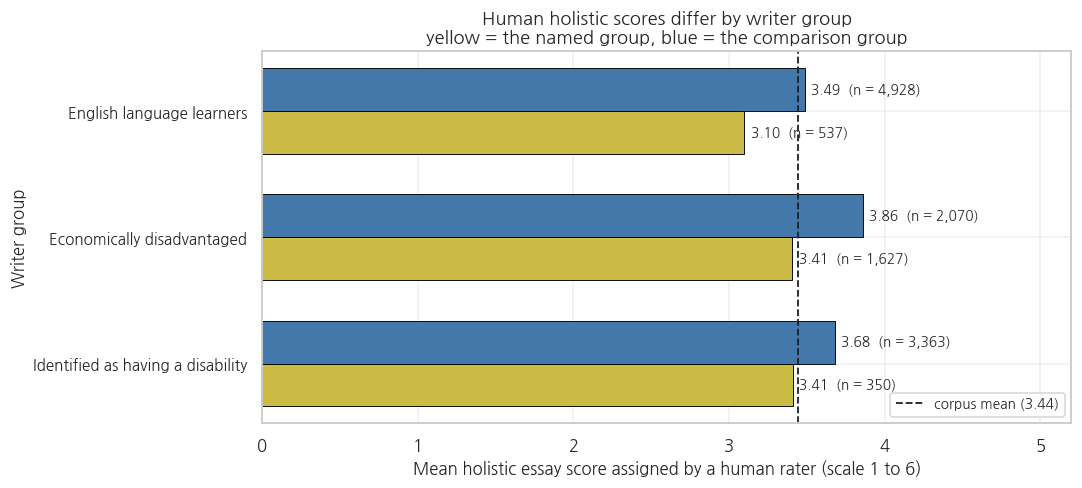

In [28]:
fig, ax = plt.subplots(figsize=(10, 4.6))

rows = [
    ('English language learners', 3, 'Yes', 'No', ell_df, 'ell_status'),
    ('Economically disadvantaged', 2, 'Economically disadvantaged',
     'Not economically disadvantaged', econ_df, 'economically_disadvantaged'),
    ('Identified as having a disability', 1, 'Identified as having disability',
     'Not identified as having disability', dis_df, 'student_disability_status'),
]
h = 0.34
for label, y, focal, ref, df, col in rows:
    fa = df.loc[df[col] == focal, 'holistic_essay_score']
    fb = df.loc[df[col] == ref, 'holistic_essay_score']
    ax.barh(y + h / 2, fb.mean(), height=h, color=BLUE, edgecolor='black', linewidth=0.6)
    ax.barh(y - h / 2, fa.mean(), height=h, color=YELLOW, edgecolor='black', linewidth=0.6)
    ax.text(fb.mean() + 0.04, y + h / 2, f'{fb.mean():.2f}  (n = {len(fb):,})',
            va='center', fontsize=9)
    ax.text(fa.mean() + 0.04, y - h / 2, f'{fa.mean():.2f}  (n = {len(fa):,})',
            va='center', fontsize=9)

ax.set_yticks([r[1] for r in rows])
ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_ylabel('Writer group')
ax.set_xlabel('Mean holistic essay score assigned by a human rater (scale 1 to 6)')
ax.set_xlim(0, 5.2)
ax.set_title('Human holistic scores differ by writer group\n'
             'yellow = the named group, blue = the comparison group')
ax.axvline(essays['holistic_essay_score'].mean(), color='#222222', linestyle='--',
           linewidth=1.2, label=f'corpus mean ({essays["holistic_essay_score"].mean():.2f})')
ax.legend(fontsize=9, loc='lower right')
plt.show()

**🧠 Interpret this figure.** Three gaps in the scores raters assigned, all in the same direction, none of them enormous:

- Writers classified as English language learners average **3.10** (n = 537) against **3.49** for the rest (n = 4,928). Gap 0.39 points, Cohen's d = -0.33, 95% CI [-0.42, -0.24].
- Writers classified as economically disadvantaged average **3.41** (n = 1,627) against **3.86** (n = 2,070). Gap 0.45, d = -0.40, CI [-0.46, -0.33].
- Writers identified as having a disability average **3.41** (n = 350) against **3.68** (n = 3,363). Gap 0.27, d = -0.24, CI [-0.35, -0.13]. That interval is the widest of the three because the group has 350 essays in it, and a chart that drew all three bars the same width would hide that.

First, read the axis label carefully. This figure plots **the score a human rater assigned**, disaggregated by **three labels a school system assigned**. Neither side of it is a property of a person. "English language learner" in particular is an administrative classification whose criteria, reclassification rules, and exit tests differ from state to state, so the ELL bar pools students at very different distances from a district's own threshold.

Now the steelman, because it deserves one. A skeptical reader could say: writing is hard, these groups face documented barriers in school, of course the scores differ, and a holistic score is supposed to reflect the quality of the essay. That reader is not being unreasonable. Notice only what the argument assumes without stating it, which is that the holistic score measures the essay and nothing else.

So let us look at something the holistic score cannot explain away. But first, one methodological detour that will change how you read the ELL number.

In [29]:
print('The same ELL comparison, computed separately inside each prompt:')
within = ell_df.pivot_table(index='prompt_short', columns='ell_status',
                            values='holistic_essay_score', aggfunc=['mean', 'size'])
within.columns = ['mean (non-ELL)', 'mean (ELL)', 'n (non-ELL)', 'n (ELL)']
within['gap'] = (within['mean (ELL)'] - within['mean (non-ELL)']).round(3)
within['ELL share of prompt'] = (100 * within['n (ELL)'] /
                                 (within['n (ELL)'] + within['n (non-ELL)'])).round(1)
print(within.round(3).to_string())
print()
overall = (ell_df.loc[ell_df['ell_status'] == 'Yes', 'holistic_essay_score'].mean()
           - ell_df.loc[ell_df['ell_status'] == 'No', 'holistic_essay_score'].mean())
print(f'Gap computed on the whole corpus at once : {overall:+.3f}')
print(f'Smallest gap inside any single prompt    : {within["gap"].max():+.3f}')
print(f'Largest gap inside any single prompt     : {within["gap"].min():+.3f}')
print()
print('Two ways to summarise the four within-prompt gaps as one number, because')
print('"larger than the pooled gap" is worth putting a size on:')
print(f'   plain average of the four                          : '
      f'{within["gap"].mean():+.3f}')
print(f'   weighted by how many ELL-classified essays a prompt holds : '
      f'{np.average(within["gap"], weights=within["n (ELL)"]):+.3f}')
print(f'   ratio of each to the pooled gap                    : '
      f'{within["gap"].mean() / overall:.1f}x and '
      f'{np.average(within["gap"], weights=within["n (ELL)"]) / overall:.1f}x')
print()
print('Mean essay length in words, by ELL status:')
print(ell_df.groupby('ell_status')['essay_word_count'].mean().round(1).to_string())
print()
print('And the same, inside each prompt:')
print(ell_df.pivot_table(index='prompt_short', columns='ell_status',
                         values='essay_word_count', aggfunc='mean').round(1).to_string())

The same ELL comparison, computed separately inside each prompt:
                   mean (non-ELL)  mean (ELL)  n (non-ELL)  n (ELL)    gap  ELL share of prompt
prompt_short                                                                                   
cell phones                 3.077       2.588          795       34 -0.488                  4.1
distance learning           4.744       3.409         1124      374 -1.335                 25.0
driverless cars             3.235       2.655         1262       58 -0.579                  4.4
electoral college           3.051       2.070         1747       71 -0.981                  3.9

Gap computed on the whole corpus at once : -0.390
Smallest gap inside any single prompt    : -0.488
Largest gap inside any single prompt     : -1.335

Two ways to summarise the four within-prompt gaps as one number, because
"larger than the pooled gap" is worth putting a size on:
   plain average of the four                          : -0.846
   weighted by

**🧠 Interpret this table carefully. It is the statistical trap of the week.**

The corpus-wide ELL gap is **-0.39 points**. The gap inside every single prompt is **larger than that**: -0.49 for cell phones, -0.58 for driverless cars, -0.98 for the electoral college, and **-1.34** for distance learning.

How can the overall gap be smaller than every part of it? Look at the last column. **25 percent of the distance learning essays were written by ELL students**, against about 4 percent everywhere else. And distance learning is the highest scoring prompt in the corpus (mean 4.41 against 3.01 for the electoral college). So ELL writers are concentrated in the easy prompt, and that concentration masks most of the gap when you pool.

This is Simpson's paradox, and it is not an exotic curiosity. It is what happens whenever a group is unevenly distributed across conditions, which in education is always. **If you had reported the pooled number you would have understated the gap by a factor of two to three, and your analysis would have looked more careful than an analysis that did not aggregate at all.** The printout gives both summaries so you can see where that range comes from: the plain average of the four within-prompt gaps is -0.85, which is 2.2 times the pooled -0.39, and weighting each prompt by how many ELL-classified essays it actually holds gives -1.15, which is 3.0 times. Neither is *the* right number. Which one you want depends on whether you are asking about the four prompts or about these writers, and saying which you chose is the whole job.

The length rows underneath make the same point twice. Pooled, the two groups produce essays of almost identical length: **446 words against 448**. Inside each prompt, ELL-classified writers' essays are shorter in three of the four (483 against 621 under distance learning) and level in the fourth. Pooling does not reverse that comparison, it **erases** it: a 138-word difference inside the prompt where two thirds of the ELL-classified essays sit arrives as a 1.3-word difference overall. The strongest predictor in this dataset becomes invisible the moment you aggregate over a condition the two groups are unevenly spread across.

### The sharper question: the same rhetorical move, rated differently

Essay scores are a summary judgment about a whole text, and whole texts differ in a hundred ways. So narrow it.

Take one **specific rhetorical move** and ask how it was rated. A Counterclaim is a Counterclaim: the annotator already decided that this span is a student stating the opposing side's reason. That structural judgment is done. The only remaining question is how well the rater thought it was executed.

In [30]:
span_dem = rated.merge(
    essays[['essay_id', 'ell_status', 'economically_disadvantaged',
            'student_disability_status', 'prompt_short']],
    on='essay_id', how='left')
span_ell = span_dem[span_dem['ell_status'].isin(['Yes', 'No'])]

print(f'Rated spans whose writer has an ELL status recorded: {len(span_ell):,} '
      f'of {len(rated):,}')
print()
print('Percent of spans rated EFFECTIVE, by move and by ELL status:')
tab = pd.crosstab([span_ell['discourse_type'], span_ell['ell_status']],
                  span_ell['discourse_effectiveness'], normalize='index') * 100
counts = span_ell.groupby(['discourse_type', 'ell_status']).size()
tab['n spans'] = counts
print(tab[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1).to_string())
print()
print('Across every move at once:')
allmoves = pd.crosstab(span_ell['ell_status'], span_ell['discourse_effectiveness'],
                       normalize='index') * 100
allmoves['n spans'] = span_ell.groupby('ell_status').size()
print(allmoves[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1).to_string())

Rated spans whose writer has an ELL status recorded: 54,492 of 55,068

Percent of spans rated EFFECTIVE, by move and by ELL status:
discourse_effectiveness          Effective  Adequate  Ineffective  n spans
discourse_type       ell_status                                           
Claim                No               18.6      78.4          3.1    17048
                     Yes               5.6      89.3          5.1     1945
Concluding Statement No               23.6      72.6          3.8     4405
                     Yes              10.6      81.7          7.7      470
Counterclaim         No               17.1      79.3          3.6     2762
                     Yes               5.5      91.4          3.1      291
Evidence             No               21.9      70.4          7.6    15065
                     Yes               6.6      82.0         11.4     1645
Lead                 No               26.8      69.9          3.3     2902
                     Yes               8.1 

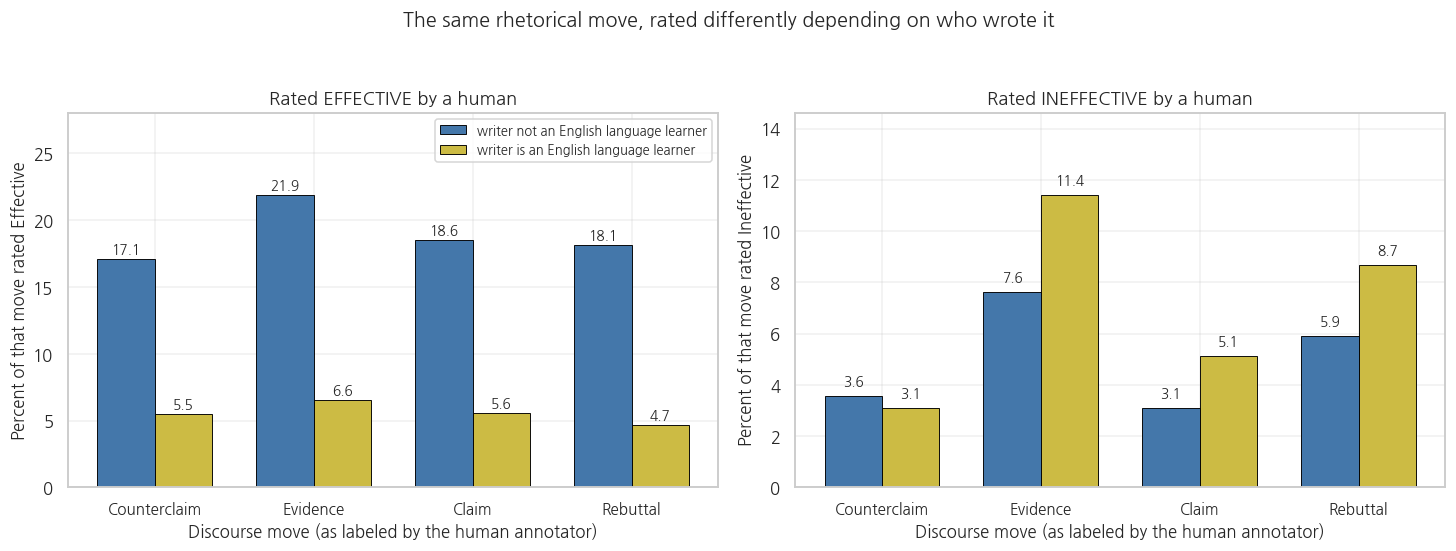

In [31]:
focus = ['Counterclaim', 'Evidence', 'Claim', 'Rebuttal']
eff = (pd.crosstab([span_ell['discourse_type'], span_ell['ell_status']],
                   span_ell['discourse_effectiveness'], normalize='index') * 100)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), sharey=False)
xs = np.arange(len(focus))
w = 0.36

for ax, outcome, ttl in zip(
        axes, ['Effective', 'Ineffective'],
        ['Rated EFFECTIVE by a human', 'Rated INEFFECTIVE by a human']):
    non = [eff.loc[(m, 'No'), outcome] for m in focus]
    ell = [eff.loc[(m, 'Yes'), outcome] for m in focus]
    ax.bar(xs - w / 2, non, width=w, color=BLUE, edgecolor='black', linewidth=0.6,
           label='writer not an English language learner')
    ax.bar(xs + w / 2, ell, width=w, color=YELLOW, edgecolor='black', linewidth=0.6,
           label='writer is an English language learner')
    for x, v in zip(xs - w / 2, non):
        ax.text(x, v + 0.4, f'{v:.1f}', ha='center', fontsize=9)
    for x, v in zip(xs + w / 2, ell):
        ax.text(x, v + 0.4, f'{v:.1f}', ha='center', fontsize=9)
    ax.set_xticks(xs)
    ax.set_xticklabels(focus, fontsize=10)
    ax.set_xlabel('Discourse move (as labeled by the human annotator)')
    ax.set_ylabel(f'Percent of that move rated {outcome}')
    ax.set_title(ttl)
    ax.set_ylim(0, max(max(non), max(ell)) * 1.28)
axes[0].legend(fontsize=8.5, loc='upper right')
plt.suptitle('The same rhetorical move, rated differently depending on who wrote it',
             fontsize=13, y=1.04)
plt.show()

### One more thing to do before you interpret that figure

Those bars are percentages of **spans**, and spans are not independent of each other. The 5,342 spans written by ELL-classified writers come from 537 essays, which is 537 people writing on one day under one set of conditions. All eleven or so spans inside one essay share that writer, that prompt, that sitting, and in most cases that rater.

If you compute an interval as though you had 5,342 independent observations, you will get an interval built for a sample about four times larger than the one you actually have. The next cell prints both widths so you can see that factor rather than take it from a sentence. The fix is standard and it is one line of thinking: **resample essays, not spans.** Draw 537 essays with replacement, take whatever spans come with each one, recompute, repeat.



In [32]:
# ---------------------------------------------------------------------------
# An essay-clustered bootstrap. Resample ESSAYS with replacement; each drawn
# essay brings all of its spans along. This is the honest unit here, because
# one essay is one writer on one day and its spans move together.
# ---------------------------------------------------------------------------
boot_rng = np.random.default_rng(RANDOM_STATE)


def clustered_gap(df, outcome, n_boot=2000):
    """ELL minus non-ELL in the percent of spans rated `outcome`, in percentage
    points, with a 95 percent interval built by resampling essays."""
    hit = (df['discourse_effectiveness'] == outcome).astype(int)
    per_essay = (pd.DataFrame({'essay': df['essay_id'].to_numpy(),
                               'ell': df['ell_status'].to_numpy(),
                               'hit': hit.to_numpy()})
                 .groupby(['ell', 'essay']).agg(k=('hit', 'sum'), n=('hit', 'size')))
    rate = {}
    for status in ['Yes', 'No']:
        k = per_essay.loc[status, 'k'].to_numpy()
        n = per_essay.loc[status, 'n'].to_numpy()
        pick = boot_rng.integers(0, len(k), (n_boot, len(k)))
        rate[status] = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    point = 100 * (hit[df['ell_status'] == 'Yes'].mean()
                   - hit[df['ell_status'] == 'No'].mean())
    lo, hi = np.percentile(rate['Yes'] - rate['No'], [2.5, 97.5])
    return point, lo, hi


print('THE SAME COMPARISON, WITH AN INTERVAL THAT RESAMPLES ESSAYS')
print('(gap = ELL minus non-ELL in the percent of that move rated Effective)')
print()
print(f'  {"move":<22}{"spans, non-ELL / ELL":>24}{"essays, non-ELL / ELL":>24}'
      f'{"gap (pp)":>11}   95% interval')
for move in ['Lead', 'Position', 'Claim', 'Counterclaim', 'Rebuttal',
             'Evidence', 'Concluding Statement']:
    part = span_ell[span_ell['discourse_type'] == move]
    point, lo, hi = clustered_gap(part, 'Effective')
    ns = (f"{int((part['ell_status'] == 'No').sum()):,} / "
          f"{int((part['ell_status'] == 'Yes').sum()):,}")
    ne = (f"{part.loc[part['ell_status'] == 'No', 'essay_id'].nunique():,} / "
          f"{part.loc[part['ell_status'] == 'Yes', 'essay_id'].nunique():,}")
    print(f'  {move:<22}{ns:>24}{ne:>24}{point:>+11.1f}   [{lo:+.1f}, {hi:+.1f}]')

point, lo, hi = clustered_gap(span_ell, 'Effective')
print()
print(f'  {"every move together":<22}{"":>48}{point:>+11.1f}   [{lo:+.1f}, {hi:+.1f}]')
pt_i, lo_i, hi_i = clustered_gap(span_ell, 'Ineffective')
print(f'  {"the same, Ineffective":<22}{"":>48}{pt_i:>+11.1f}   [{lo_i:+.1f}, {hi_i:+.1f}]')

# And what the shortcut would have bought us.
hit_eff = (span_ell['discourse_effectiveness'] == 'Effective').astype(int)
a = hit_eff[span_ell['ell_status'] == 'Yes']
b = hit_eff[span_ell['ell_status'] == 'No']
naive_half = 1.96 * 100 * np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
print()
print('On the "every move together" line:')
print(f'  half-width of the interval above, resampling essays        : {(hi - lo) / 2:.2f} pp')
print(f'  half-width if all {len(span_ell):,} spans were treated as independent : '
      f'{naive_half:.2f} pp')
print('The second number is the one that appears in a lot of published work. It is')
print('too small, because 5,342 ELL spans are 537 people, not 5,342 people. Note also')
print('that the wider interval still does not come close to zero: the honest version')
print('of this finding is smaller than the careless one and it survives.')


THE SAME COMPARISON, WITH AN INTERVAL THAT RESAMPLES ESSAYS
(gap = ELL minus non-ELL in the percent of that move rated Effective)

  move                      spans, non-ELL / ELL   essays, non-ELL / ELL   gap (pp)   95% interval


  Lead                               2,902 / 308             2,901 / 308      -18.7   [-22.0, -15.0]


  Position                           4,916 / 533             4,902 / 531      -10.3   [-12.0, -8.5]
  Claim                           17,048 / 1,945             4,778 / 517      -12.9   [-14.7, -11.2]
  Counterclaim                       2,762 / 291             2,071 / 213      -11.6   [-14.7, -7.7]


  Rebuttal                           2,052 / 150             1,628 / 133      -13.5   [-17.8, -8.1]


  Evidence                        15,065 / 1,645             4,913 / 535      -15.4   [-17.3, -13.3]


  Concluding Statement               4,405 / 470             4,375 / 470      -13.0   [-16.0, -9.8]

  every move together                                                         -13.7   [-15.1, -12.2]


  the same, Ineffective                                                        +2.7   [+1.4, +4.0]

On the "every move together" line:
  half-width of the interval above, resampling essays        : 1.43 pp
  half-width if all 54,492 spans were treated as independent : 0.74 pp
The second number is the one that appears in a lot of published work. It is
too small, because 5,342 ELL spans are 537 people, not 5,342 people. Note also
that the wider interval still does not come close to zero: the honest version
of this finding is smaller than the careless one and it survives.


**🧠 Interpret this figure. This is the finding the week is built around.**

Read every count twice, once as spans and once as people, because the cell above prints both.

Among spans that a human annotator already identified as a **Counterclaim**, and therefore already credited as the student having produced a counterclaim:

- **17.1 percent** of those written by non-ELL students were rated Effective (2,762 spans, 2,071 essays).
- **5.5 percent** of those written by ELL students were rated Effective (291 spans, 213 essays, which is sixteen spans in total).
- The gap is **-11.6 percentage points**, 95 percent interval **[-14.7, -7.7]**, resampling essays rather than spans.

Among **Evidence** spans:

- **21.9 percent** effective for non-ELL writers (15,065 spans, 4,913 essays) against **6.6 percent** for ELL writers (1,645 spans, 535 essays). Gap **-15.4**, 95 percent **[-17.3, -13.3]**.
- And the Ineffective ratings run the other way: **7.6 percent** against **11.4 percent**.

Across all moves together: writers not classified as ELL get **19.9 percent** Effective and **4.6 percent** Ineffective (49,150 spans from 4,928 essays). Writers the district classified as ELL get **6.2 percent** Effective and **7.2 percent** Ineffective (5,342 spans from 537 essays). The Effective gap is **-13.7 points, 95 percent [-15.1, -12.2]**, the Ineffective gap **+2.7, 95 percent [+1.4, +4.0]**, and all seven per-move intervals fall on the same side of zero. A move by an ELL-classified writer is about **one third as likely** to be called Effective and about **one and a half times as likely** to be called Ineffective.

**What that interval did, and what it did not do.** It nearly doubled the width of the headline comparison, from 0.74 points to 1.43, which is what it costs to admit that 5,342 spans are 537 people. It also left the finding standing, which is the more useful outcome: a result that survives only when clustered data is treated as independent was never a result. What no interval can do is say *why* the ratings differ. That is the next part, and it is not a statistical question.

This is not the essay score. The structural work is already credited. The move is on the page and the annotator has named it. What differs is the judgment of how well it was done.

### We are not going to resolve this for you

There are at least four readings. Take them in the order this course takes them: what the instrument did, what the construct did, what the file does not record, and only then anything about the writers.

1. **The instrument.** "Effective" is a judgment a person made, under a rubric, at a pace, for a fee, on writing whose surface carries its writer. Features common in second-language writing (article choice, unusual collocations, prepositions) are highly salient to a reader and are known to pull global judgments of quality even when raters are instructed to set them aside. Under this reading the ratings are contaminated and the error runs in one direction.
2. **The construct.** "Effective" is defined by a rubric written by somebody, and a rubric encodes a norm about what a good argument sounds like. Under this reading nobody made an error at all: the gap is the rubric doing exactly what it was designed to do, applied to students whose rhetoric was not what it was designed around.
3. **The setting and the circumstances.** This file records a score and five demographic fields. It does not record how much of the period the student had left, whether they had a testing accommodation, how long they had been in an English-medium school, what writing instruction they had received, or what "ELL" means in the district that applied the label. That last one carries weight: ELL is an administrative classification with state-by-state criteria, so a gap between ELL and non-ELL is partly a fact about classification systems.
4. **The writing.** A student writing in a language they are still acquiring may produce counterclaims that are structurally present and less fluently executed, and a rater noticing that is doing their job. This reading is live and you should not delete it. Notice only that it is fourth on the list rather than first, and that this file gives you no more evidence for it than for the other three.

Reading 1 says fix the raters. Reading 2 says fix the construct. Reading 3 says fix the conditions, and stop treating a district label as a property of a child. Reading 4 says fix the instruction. They are not mutually exclusive, and you cannot weigh them from this file. **You would need rater-level identifiers, essays scored blind to writer status, a second panel working from a different rubric, or the schooling history this corpus does not carry.** None of those are here.

What you may **not** conclude on this evidence is that these students write worse. That sentence requires the instrument to be neutral, and the next cell is a direct test of whether it is.

The readings this week give you the vocabulary. **Allen, Creer, and Öncel** on the multi-dimensionality of language as evidence. **Gibson and Shibani** on the distance between what a writing analytics tool measures and what a teacher should be handed. **Dowell and Kovanović** on discourse as structure rather than surface. Take a position and defend it in the memo. Do not write "more research is needed."

In [33]:
# Section 7 has been pooling across four prompts. Section 7's own Simpson's
# paradox detour is the reason we cannot leave it there, so run the same
# comparison one prompt at a time and see whether the finding survives.
per_prompt = (pd.crosstab([span_ell['prompt_short'], span_ell['ell_status']],
                          span_ell['discourse_effectiveness'], normalize='index') * 100)
per_prompt['n spans'] = span_ell.groupby(['prompt_short', 'ell_status']).size()
print('Every rated span, split by prompt and by ELL classification:')
print(per_prompt[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1).to_string())
print()

wide = per_prompt['Effective'].unstack()
wide.columns = ['non-ELL % Effective', 'ELL % Effective']
wide['gap (pp)'] = (wide['ELL % Effective'] - wide['non-ELL % Effective'])
pooled_gap = allmoves.loc['Yes', 'Effective'] - allmoves.loc['No', 'Effective']
print(wide.round(1).to_string())
print()
print(f'Pooled over all four prompts, the gap is {pooled_gap:+.1f} percentage points.')
print(f'Inside a single prompt it runs from {wide["gap (pp)"].max():+.1f} to '
      f'{wide["gap (pp)"].min():+.1f}, and it is negative in all four.')
print()
print('Now hold the classification constant and read ONE group down the prompts.')
print('Every row below is writers NOT classified as ELL. Only the prompt changes:')
one_group = per_prompt.xs('No', level='ell_status')[['Effective', 'Ineffective', 'n spans']]
print(one_group.round(1).to_string())


Every rated span, split by prompt and by ELL classification:
discourse_effectiveness       Effective  Adequate  Ineffective  n spans
prompt_short      ell_status                                           
cell phones       No                5.4      91.4          3.1     6834
                  Yes               0.4      92.1          7.5      240
distance learning No               31.1      68.4          0.5    14439
                  Yes               6.2      88.8          5.0     4087
driverless cars   No               15.9      82.8          1.3    11579
                  Yes               6.8      88.4          4.9      473
electoral college No               18.9      70.0         11.1    16298
                  Yes               8.5      65.3         26.2      542

                   non-ELL % Effective  ELL % Effective  gap (pp)
prompt_short                                                     
cell phones                        5.4              0.4      -5.0
distance learning   

**🧠 Interpret this table. You have just applied Section 7's own lesson to Section 7's own finding, which is the check nobody does.**

**First, the finding survives.** The pooled gap is **-13.7 percentage points**. Inside a single prompt it runs from **-5.0** (cell phones) to **-24.9** (distance learning), and it is negative in all four. Pooling did here what it did to the essay scores: it made the gap look smaller than it is in the condition where most of the ELL-classified essays actually sit. Had the within-prompt gaps pointed in different directions, the headline figure above would have been an artifact and we would have had to withdraw it. They do not, so it stands.

**Second, and this is the part worth the section.** Read the last table, where the ELL classification is held constant and only the prompt changes. Within the single group of writers **not** classified as ELL, the share of spans rated Effective runs from **5.4 percent** under the cell phone prompt to **31.1 percent** under distance learning. The share rated Ineffective runs from **0.5 percent** under distance learning to **11.1 percent** under the electoral college, a twenty-fold difference.

Be precise about what that does and does not establish. These are different students in different rows, so this is **not** a within-person comparison and it does not prove the raters differed. What it establishes is that the output of this three-point scale is dominated by which pile a span came from. Four candidate causes are tangled here and this file separates none of them: different prompts, different source material, different testing sessions, and, since the prompts were assembled from more than one source (Section 1 proved that from the missingness pattern alone), quite possibly different rating panels working to differently calibrated exemplars.

That tangle is itself the point. A rating whose distribution moves this far across administrative conditions is not a neutral ruler from which you can subtract writers. Any explanation of the ELL gap that starts with the writers has skipped over a source of variation larger than the gap it is trying to explain.


In [34]:
# Now connect Section 6 to Section 7: how does the effectiveness model
# distribute its errors?
te2_dem = te2.merge(essays[['essay_id', 'ell_status']], on='essay_id', how='left')
sub = te2_dem[te2_dem['ell_status'].isin(['Yes', 'No'])]

print('THE MODEL YOU TRAINED IN SECTION 6, AUDITED BY WRITER GROUP')
print()
rows = []
for g, name in [('No', 'writer not an ELL student'), ('Yes', 'writer is an ELL student')]:
    s = sub[sub['ell_status'] == g]
    rows.append({
        'group': name,
        'test spans': len(s),
        'truly Effective': int(s['is_effective'].sum()),
        'human Effective rate': f"{100 * s['is_effective'].mean():.1f}%",
        'model flag rate': f"{100 * s['pred_effective'].mean():.1f}%",
        'recall (of the truly effective, found)':
            f"{100 * recall_score(s['is_effective'], s['pred_effective']):.1f}%",
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
def clustered_recall(df, n_boot=2000):
    """Percent of the truly Effective spans that the model flagged, with a 95
    percent interval built by resampling essays rather than spans."""
    truly = df[df['is_effective'] == 1]
    per_essay = (pd.DataFrame({'essay': truly['essay_id'].to_numpy(),
                               'hit': truly['pred_effective'].to_numpy()})
                 .groupby('essay').agg(k=('hit', 'sum'), n=('hit', 'size')))
    k, n = per_essay['k'].to_numpy(), per_essay['n'].to_numpy()
    pick = boot_rng.integers(0, len(k), (n_boot, len(k)))
    draws = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return 100 * truly['pred_effective'].mean(), lo, hi, len(truly), truly['essay_id'].nunique()


print('THE SAME TWO RECALLS WITH AN INTERVAL ON EACH')
for g, name in [('No', 'writer not an ELL student'), ('Yes', 'writer is an ELL student')]:
    r, lo, hi, ns, ne = clustered_recall(sub[sub['ell_status'] == g])
    print(f'  {name:<26} {r:>5.1f}%   95% [{lo:.1f}%, {hi:.1f}%]   '
          f'from {ns:,} effective spans in {ne:,} essays')
print()
print('The ELL interval is wide, and printing it is the point. Anyone who quotes the')
print('point estimate alone is reporting a number this file cannot pin down that')
print('precisely. What the file does support is the two intervals not overlapping.')

THE MODEL YOU TRAINED IN SECTION 6, AUDITED BY WRITER GROUP

                    group  test spans  truly Effective human Effective rate model flag rate recall (of the truly effective, found)
writer not an ELL student       12267             2445                19.9%           10.4%                                  31.8%
 writer is an ELL student        1363               88                 6.5%            3.3%                                  14.8%

THE SAME TWO RECALLS WITH AN INTERVAL ON EACH


  writer not an ELL student   31.8%   95% [29.8%, 33.9%]   from 2,445 effective spans in 1,418 essays
  writer is an ELL student    14.8%   95% [7.3%, 23.2%]   from 88 effective spans in 60 essays

The ELL interval is wide, and printing it is the point. Anyone who quotes the
point estimate alone is reporting a number this file cannot pin down that
precisely. What the file does support is the two intervals not overlapping.


**🧠 Interpret this last table, and then stop and see what you have built.**

The model finds **31.8 percent** of the genuinely effective spans written by non-ELL students, 95 percent interval **[29.8, 33.9]**, and **14.8 percent** of those written by ELL students, 95 percent interval **[7.3, 23.2]**. It flags ELL students' writing as effective at **3.3 percent** against **10.4 percent**.

Read the second interval before you quote the second number. It rests on 88 effective spans written by 60 people. This file can support "the model recovers fewer of these writers' effective moves, and the two intervals do not overlap." It cannot support "one in seven" as a precise figure, because one in fourteen and one in four are both inside the interval. Both of those sentences are worth saying out loud. In practice only the first half usually gets said.

Trace the chain, because every link is something you did in this notebook:

1. Human raters called ELL students' moves Effective about a third as often (Section 7).
2. You trained a bag-of-words model on those labels (Section 6).
3. The model learned that pattern, because that is what training is.
4. Deployed as feedback, it would tell ELL students they had written something effective about a seventh of the time it should, with the interval on that running from about one in fourteen to about one in four.

**Nobody put a demographic variable in this model.** There is no `ell_status` column in the feature matrix. The features are counts of English words. And in Section 5 you already watched an unsupervised topic model partly recover ELL status from word counts alone, without even being asked to.

This is the week's **Affordances and Limits** entry, made concrete: an automated writing scorer trained on these labels inherits this pattern, and it inherits it silently, and its accuracy number stays at 83 percent the whole time.

One more honest note. The gap in the *model's* behavior is smaller than the gap in the *humans'* behavior would predict, mostly because the model barely flags anything as effective for anyone. That is not fairness. That is a model too timid to be unfair loudly, which is a different thing and not an improvement.

---

## 📊 8. Stretch: does the pattern hold for other groups and other moves?

*(This section is the stretch goal. The core deliverable is complete without it. Attempt it if you have time or want a stronger analysis section in your memo.)*

You tested one grouping variable (ELL status) on two moves. The obvious next question is whether the pattern is specific to language status or whether any grouping of students produces gaps like this. That is a real question with a checkable answer, and the answer is not the same for every column.

### ✏️ Your turn 5: pick a group and a move

`GROUP_COLUMN` and `MOVE` below default to `economically_disadvantaged` and `Evidence`. Any of these will run:

- `GROUP_COLUMN`: `'economically_disadvantaged'`, `'student_disability_status'`, `'gender'`, `'ell_status'`, `'race_ethnicity'`
- `MOVE`: any of `Claim`, `Evidence`, `Position`, `Counterclaim`, `Rebuttal`, `Lead`, `Concluding Statement`

Try `gender` before you decide the pattern is universal.

Move: Evidence   |   Grouping: economically_disadvantaged
Spans used: 11,523. Spans dropped because the field was blank: 5,365

discourse_effectiveness         Effective  Adequate  Ineffective  n spans
economically_disadvantaged                                               
Economically disadvantaged           15.1      80.6          4.3     4917
Not economically disadvantaged       26.6      71.4          1.9     6606

Spread in the Effective rate across groups: 11.5 percentage points



"Economically disadvantaged" minus "Not economically disadvantaged", in the percent rated Effective:
   -11.5 percentage points, 95% [-13.8, -9.3], resampling essays
   Essays behind those spans: 1,627 and 2,069
   Prompts these spans come from: cell phones, distance learning, driverless cars


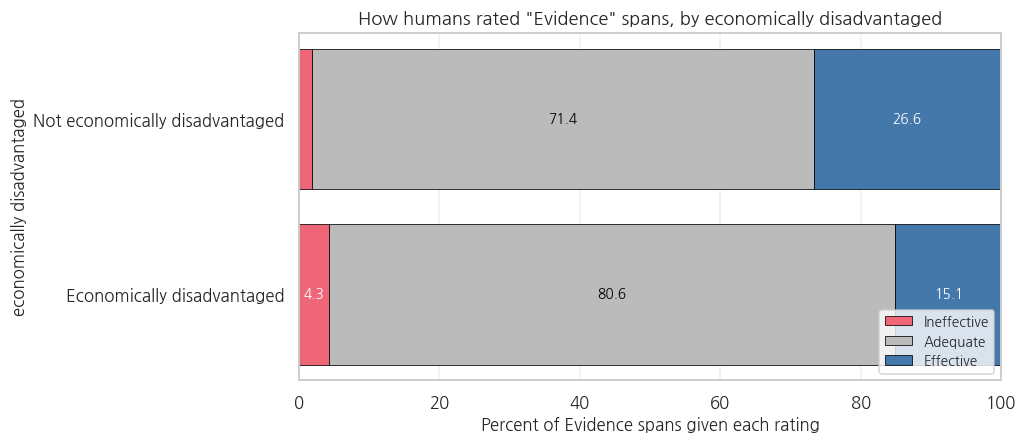

In [35]:
# TODO (optional): change either of these two values and re-run.
GROUP_COLUMN = 'economically_disadvantaged'
MOVE = 'Evidence'

sel = span_dem[span_dem['discourse_type'] == MOVE].copy()
sel = sel[sel[GROUP_COLUMN].notna() &
          (sel[GROUP_COLUMN].astype(str).str.strip() != '')]

tab = pd.crosstab(sel[GROUP_COLUMN], sel['discourse_effectiveness'],
                  normalize='index') * 100
tab['n spans'] = sel.groupby(GROUP_COLUMN).size()
tab = tab[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1)

print(f'Move: {MOVE}   |   Grouping: {GROUP_COLUMN}')
print(f'Spans used: {len(sel):,}. '
      f'Spans dropped because the field was blank: '
      f'{int((span_dem["discourse_type"] == MOVE).sum()) - len(sel):,}')
print()
print(tab.to_string())
print()
spread = tab['Effective'].max() - tab['Effective'].min()
print(f'Spread in the Effective rate across groups: {spread:.1f} percentage points')
print()

# Same discipline as Section 7: spans come in essay-sized clumps, so resample essays.
levels = list(tab.index)
if len(levels) == 2:
    focal, ref = levels
    hit = (sel['discourse_effectiveness'] == 'Effective').astype(int)
    per_essay = (pd.DataFrame({'essay': sel['essay_id'].to_numpy(),
                               'g': sel[GROUP_COLUMN].to_numpy(),
                               'hit': hit.to_numpy()})
                 .groupby(['g', 'essay']).agg(k=('hit', 'sum'), n=('hit', 'size')))
    draw = {}
    for g in (focal, ref):
        k = per_essay.loc[g, 'k'].to_numpy()
        n = per_essay.loc[g, 'n'].to_numpy()
        pick = boot_rng.integers(0, len(k), (2000, len(k)))
        draw[g] = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    lo, hi = np.percentile(draw[focal] - draw[ref], [2.5, 97.5])
    point = 100 * (hit[sel[GROUP_COLUMN] == focal].mean()
                   - hit[sel[GROUP_COLUMN] == ref].mean())
    print(f'"{focal}" minus "{ref}", in the percent rated Effective:')
    print(f'   {point:+.1f} percentage points, 95% [{lo:+.1f}, {hi:+.1f}], resampling essays')
    print(f'   Essays behind those spans: '
          f'{sel.loc[sel[GROUP_COLUMN] == focal, "essay_id"].nunique():,} and '
          f'{sel.loc[sel[GROUP_COLUMN] == ref, "essay_id"].nunique():,}')
    print(f'   Prompts these spans come from: '
          f'{", ".join(sorted(sel["prompt_short"].unique()))}')
else:
    print(f'{len(levels)} groups here, so no two-group interval is printed. With this many')
    print('cells, describe the gradient across them rather than hunting the largest single')
    print('gap, and check the span counts before you believe any of the small ones.')

groups = list(tab.index)
fig, ax = plt.subplots(figsize=(9.5, 0.9 * len(groups) + 2.4))
left = np.zeros(len(groups))
for col, colr in [('Ineffective', ROSE), ('Adequate', GREY), ('Effective', BLUE)]:
    ax.barh(groups, tab[col], left=left, color=colr, edgecolor='black',
            linewidth=0.5, label=col)
    for y, (v, l) in enumerate(zip(tab[col], left)):
        if v > 3:
            ax.text(l + v / 2, y, f'{v:.1f}', ha='center', va='center', fontsize=9,
                    color='white' if col != 'Adequate' else 'black')
    left = left + tab[col].values
ax.set_xlabel(f'Percent of {MOVE} spans given each rating')
ax.set_ylabel(GROUP_COLUMN.replace('_', ' '))
ax.set_title(f'How humans rated "{MOVE}" spans, by {GROUP_COLUMN.replace("_", " ")}')
ax.set_xlim(0, 100)
ax.legend(fontsize=9, loc='lower right')
plt.show()

**🧠 Interpret this comparison.** With the shipped defaults, `Evidence` spans by writers classified as economically disadvantaged were rated Effective **15.1 percent** of the time (4,917 spans, 1,627 essays) against **26.6 percent** for the rest (6,606 spans, 2,069 essays), and Ineffective **4.3 percent** against **1.9 percent**. The gap is **-11.5 points, 95 percent [-13.8, -9.3]**, resampling essays as Section 7 did. Same shape as the ELL result, on a different column.

Now change `GROUP_COLUMN` to `'gender'` and re-run. The Effective rate for `Evidence` is 22.5 percent for F and 17.9 percent for M (8,917 and 7,971 spans), a gap of **+4.6 points**, 95 percent interval roughly **[+2.7, +6.4]**. It is distinguishable from zero, it is smaller than half the economic gap, and it runs in the opposite direction.

**One caution before you set those two numbers side by side.** They are not computed on the same corpus. Economic status is blank for every electoral college essay, so the economic comparison rests on three prompts; gender is recorded everywhere, so the gender comparison rests on four. The cell prints the prompt list under each result for exactly this reason. Restricting gender to the same three prompts moves it to about +5.6, which does not change the conclusion, and checking rather than assuming is the habit worth keeping.

That contrast is the point of the stretch, and state it carefully. **The gaps are not all the same size, and the largest of them fall on the classifications that track schooling conditions rather than on the ones that do not.** Which is why "the raters were reading the writer" and "these students had different opportunities to learn" are both still live, and why a column that shows a gap is evidence for neither on its own. Note also that both of those explanations sit outside the student: one is about the instrument, one is about the school.

And one arithmetic caution for the whole of Section 8. Five grouping columns times seven moves is thirty-five comparisons available from this one cell. Run them all and report the biggest and you have found the largest of thirty-five numbers, which is not the same thing as a finding. Choose the comparison before you look, or say how many you ran.

If you want to push further: run `student_disability_status` on `Counterclaim`. That is 183 spans from 135 essays in one group, the gap lands near -4.5 points, and its interval runs from roughly -10 to +2. It contains zero. The right report is "we cannot distinguish this from noise on 183 spans," not the point estimate on its own.

---

## 💬 Reflection and the interpretation memo

### Tie it to the readings

This week's required readings all argue, in different registers, that language is a legitimate and difficult source of evidence about learning.

- **Allen, Creer, and Öncel (2022)** make the case for a multi-dimensional view of learning through natural language processing: no single index of a text captures what a learner is doing. You built several indices in this notebook (a stance lexicon, a word count, a topic assignment, two classifiers), and the crudest one was the strongest. Is that the multi-dimensionality these authors describe, or is it a warning that the dimensions we can measure easily are not the ones that matter? Argue it either way, but argue it.
- **Gibson and Shibani (2022)** write about writing analytics and about the distance between what a tool measures and what a teacher should actually be handed. Take one number from this notebook, any number, and ask whether you would show it to the fourteen-year-old who wrote the essay. If not, why did you compute it? If yes, what would you say alongside it?
- **Dowell and Kovanović (2022)** model educational discourse as a social and structural process rather than a bag of words. Section 6 gave you the sharpest possible illustration: your classifier recovers Position and Evidence, which are defined by their own content, and collapses on Counterclaim and Rebuttal, which are defined by their relationship to other moves. Name one thing their approach can see that a span-level bag of words structurally cannot.
- **Dowell, Lin, Godfrey, and Brooks (2020)**, in the additional readings, connect emergent sociocognitive roles to collaborative outcomes. If you wanted to extend this notebook toward roles rather than moves, what would you need beyond an essay corpus?

Our guest this week is **Jiayi (Joyce) Zhang** of the University of Pennsylvania. Bring a question from your own analysis, not a generic one. "When human ratings show a gap by writer group, how do you decide whether to train on them anyway?" is a better use of the visit than "what is the best sentiment tool?"

### Questions to sit with

1. Section 1 showed that one third of this corpus is missing economic and disability status, and that the hole is exactly one prompt. You made a decision about it. Somebody upstream made a decision before you. Which of the two decisions has more effect on what can be concluded, and which one is documented?
2. The strongest single predictor of a human holistic score in this corpus is **how many words the student wrote** (r = 0.559). Is that a fact about writing, a fact about raters, or a fact about testing conditions? What would you need in order to tell?
3. You trained a model that reports 83.4 percent accuracy and misses 69 percent of the effective writing. If a vendor showed you the first number, what is the exact question you would ask to get to the second?
4. These essays were written by children in a testing session and released for research. Nothing in this notebook was unethical, and yet you have spent an hour computing group differences in how their writing was judged. Write down one thing you would refuse to publish from this analysis, and who you would be protecting.
5. Suppose all three readings of the Section 7 finding are partly true. What would a responsible district do on Monday?

### ✍️ Your interpretation memo (about 300 words)

**Write it in the cell below.** Double-click the cell to edit it, replace the bracketed prompts, and keep the headings. This memo is graded, and it is where the analytical work of the mini project actually lives.

### Interpretation memo

**Name:**
**Date:**

**What I found.**
[Two or three sentences on the substantive result. What is true of this corpus? Use at least two specific numbers from this notebook and say which cell produced each.]

**The finding I had to interpret.**
[Take the Section 7 result. Which of the three readings do you find most credible, and why? What specific evidence in the notebook supports your choice, and what evidence cuts against it? Say explicitly what a reader who chose a different reading would conclude and why you rejected it. Do not write that more research is needed.]

**What my choices did to my results.**
[Name two decisions you made in this notebook: your stopword list, your lexicon edits, your number of topics, the choice to collapse effectiveness to two categories, the choice to split spans at random rather than by essay, or the choice to drop rather than impute the missing demographic fields. For each, state what a different reasonable choice would have changed.]

**Limits, ethics, and equity.**
[Who is missing from this analysis, and what does that do to the claim? Size at least one limitation rather than only naming it. Then: if a district asked you to build a writing scorer on this corpus, what would you tell them, and what would you refuse to hand over?]

---

## ✅ Submission checklist: Mini Project 2

**Due this week, via Canvas, by the deadline posted on the Canvas assignment page for week 5 (Wednesday, September 23, 2026).** We launch this in class during the hands-on block. Most people finish it at home, and that is expected.

Three things are submitted, and all three are required for full credit.

**1. The notebook.** Upload the executed `.ipynb` file, with the outputs visible, to the **Mini Project 2** assignment on Canvas.
- [ ] Runs top to bottom without errors (use **Runtime > Restart and run all** and watch it go).
- [ ] All five **✏️ Your turn** cells attempted, even if you kept a default and explained why in a comment.
- [ ] Every figure still has a readable title and axis labels after your edits.
- [ ] Anywhere you report a number about a group, the sample size is next to it.

**2. The interpretation memo (about 300 words).** Completed in the markdown cell above, inside the notebook. If you would rather submit it as a separate document, that is fine, but it must still be in the notebook so the numbers you cite sit next to the code that produced them.

**3. The AI interaction log and reflection.** Goes to the Canvas **AI Reflection** submission, in two different places on that page.
- [ ] **The conversation record in an attached Word file.** Every relevant exchange, across every session and every tool, pasted in full. Not a summary, not a link.
- [ ] **The reflection in the Canvas text box.** Copy in the four questions from the syllabus and answer each: how you used AI; whether it helped and how; whether it made your work more challenging in any way; and what lesson about AI from this week you would pass on to a friend or the class.
- [ ] If you used no AI at all, say so in one line in the text box and attach nothing. A blank submission is not a declaration.
- Undisclosed or inappropriate AI use is an Honor Code violation. Disclosed, policy-compliant use is not penalized.

**A note specific to this week.** Text analysis is unusually easy to have an AI do for you and unusually easy to get subtly wrong. If a model writes your lexicon, names your topics, or drafts your interpretation of the Section 7 gap, say so, and then do the thing the model cannot do: open the spans, read what the students actually wrote, and check whether the interpretation survives contact with them. That checking is the assignment.

**And a note about the data.** These are real essays by real children, released under CC BY-NC-SA 4.0 for research and education. Cite the corpus in your memo (Crossley et al., 2024). Do not redistribute the text, do not use it commercially, and do not quote a long passage of a student's essay in anything public. Short illustrative spans, as the notebook prints them, are fair use for coursework.

---

## Appendix: solutions and notes for the ✏️ Your turn cells

Read these after you have tried the cells. They are notes on what each exercise was for, not answer keys, because in every case more than one answer is defensible.

### Your turn 1: corpus-specific stopwords

The shipped default removes `just, like, dont, im, people, thing, things, say, said, know, want, going`. A version aimed harder at topic separation would also remove the four prompts' shared institutional vocabulary:

```python
MY_EXTRA_STOPWORDS = ['just', 'like', 'dont', 'im', 'people', 'thing', 'things',
                      'say', 'said', 'know', 'want', 'going',
                      'students', 'student', 'school', 'schools', 'think', 'good', 'bad']
```

**The trade to notice.** Removing `students` and `school` sharpens the distinction between the driverless cars prompt and the other three, because those two words appear in three of the four. It also deletes the single most common noun in the corpus, which is the word these students use to talk about themselves. If your next analysis were about how students position themselves in an argument, you have just thrown away the evidence.

Also notice `dont` and `im`. They are in the default list because the cleaning function stripped apostrophes, turning `don't` into `dont`. That is a downstream consequence of a decision made in Section 2, and it is the kind of thing that only shows up when you look at your own frequency table.

### Your turn 2: editing the lexicon

The shipped default drops `think, believe, often, sometimes, usually, generally`. The correlation with the holistic score moves from **-0.091 to +0.077**, which is a sign flip, and it flips in rank terms too, from **rho = -0.067 to +0.141**, so it is not an artifact of having used Pearson on a six-point scale. Both are near zero and neither would survive a serious specification check, and that is the lesson: **six words changed the direction of the story.** Had you published the first version you would have written that stronger essays hedge less. Had you published the second, that stronger essays hedge more.

The defensible answer about `think` and `believe` is that they are doing two different jobs in this corpus. "I think we should ban phones" is an assertion of position with a first-person frame. "This suggests that phones might be a distraction" is a genuine epistemic hedge. A lexicon cannot tell them apart because the difference is syntactic, not lexical. If you wanted to separate them you would need a parser, which is a real answer and a much larger project.

What you should take away is not "the lexicon was bad." It is that a small transparent instrument on a large corpus can be edited into either conclusion by a reasonable person, and the only defense is publishing the word list. Which is why it is printed in the notebook.

### Your turn 3: the number of topics

Four topics reproduced the four prompts almost perfectly (adjusted Rand index 0.9996 for NMF). Eight topics dropped it to 0.595, not because the model got worse but because there is no longer a one-to-one map to check against.

The thing to notice is in the composition table. The three sub-topics NMF found inside the distance learning prompt have nearly identical mean lengths and very different ELL composition (12.7, 27.9, and 37.5 percent). **An unsupervised model given only word counts partially sorted essays by who wrote them.** If you try 12 or 20 topics, the sub-topics get smaller and this effect gets easier to see and harder to interpret, which is a fair summary of topic modeling in general.

A note on method: `adjusted_rand_score` is the right metric here precisely because it does not care what the topics are numbered. NMF topic 0 and LDA topic 3 can be the same thing. Any comparison that assumed the numbering meant something would be measuring nothing.

### Your turn 4: swapping the model and classifying your own sentences

Logistic regression takes accuracy from 0.547 to 0.680. It is a better model and you should prefer it.

It also leaves Counterclaim at 0.318 recall (down from 0.343) and Rebuttal at 0.265 (up from 0.153, and still failing most of the time). The generalizable point: **when two very different algorithms fail on the same classes, the problem is upstream of the algorithm.** Here, upstream means the representation, because the identity of a counterclaim depends on the position of the essay it sits in, and a span has no essay attached.

If you wanted to fix it properly you would give the model context: the essay's Position span, the preceding span's type, the span's relative location in the essay. That is a feature engineering problem, not a modeling problem, and it is a good course project.

On the four shipped sentences, the model most often mislabels the counterclaim ("Some people would argue that phones are too distracting in class"). Look at why. Its vocabulary is the vocabulary of a claim about phones. The words `some people would argue` are the only cue, and they are only a cue because *we* recognize the frame.

### Your turn 5: other groups, other moves

Defaults are `economically_disadvantaged` and `Evidence`: 15.1 percent Effective against 26.6, a gap of -11.5 points with a 95 percent interval of about [-13.8, -9.3], on 11,523 spans from 3,696 essays.

`student_disability_status` on `Evidence` gives 16.1 against 22.2 percent, a gap near -6.0 with an interval of about [-9.6, -2.4]: same direction, smaller, and still clear of zero.

`gender` on `Evidence` gives 22.5 percent for F against 17.9 for M, about +4.6 with an interval near [+2.7, +6.4]. Smaller, and running the other way. That comparison is the most useful one in the exercise, because it demonstrates that the pattern is not an artifact of slicing a corpus into any two groups. Something specific is going on with language status, economic status, and disability status, and the thing they have in common is not a writing feature.

Every interval in this section resamples **essays**, not spans. Section 7 shows why: one essay supplies about eleven spans, so a span count is not a sample size. On the headline ELL comparison the honest interval is nearly twice as wide as the careless one.

Be careful with `race_ethnicity`. The American Indian/Alaskan Native group has 24 essays in the whole corpus. A percentage computed on a handful of spans will bounce enormously and should not be reported as though it were an estimate of anything. Noticing that, and saying so instead of putting the bar on the chart anyway, is a real analytic skill. The cell declines to print a two-group interval for that column on purpose: with six categories the question is the pattern across them, not the largest single pair.

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · University of Virginia School of Education and Human Development.*
*Course design by Dr. Hakeoung Hannah Lee.*

*Data: PERSUADE 2.0, a four-prompt subset. Licensed CC BY-NC-SA 4.0. Crossley, S. A., Baffour, P., Tian, Y., Franklin, A., Benner, M., & Boser, U. (2024). A large-scale corpus for assessing written argumentation: PERSUADE 2.0. Assessing Writing, 61, 100865. https://doi.org/10.1016/j.asw.2024.100865*